<a href="https://colab.research.google.com/github/Caramelizeed/xgboost_quant/blob/main/research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XGBoost Quantitative Strategy — Indian Equities (NSE/BSE)

## Research Notebook

### Architecture Overview

This notebook implements a **full quantitative research pipeline** for Indian equities, structured in five layers:

```
1. Data Acquisition & Cleaning        — yfinance, corporate action adjustment
2. Feature Engineering                — technical, statistical, microstructure
3. Label Construction                 — triple-barrier method (López de Prado)
4. Model Training & Tuning            — XGBoost + Bayesian hyperopt + SHAP
5. Walk-Forward Backtesting           — combinatorial purged k-fold, position sizing
```

### Mathematical Framework

The signal generation problem is framed as a **supervised classification task** where:

- $X_t \in \mathbb{R}^d$ — feature vector at time $t$
- $y_t \in \{-1, 0, +1\}$ — directional label (short / neutral / long)
- We estimate $P(y_t | X_t)$ via gradient-boosted trees
- Position size is scaled by $P(y_t | X_t) - 0.5$ (Kelly-fractional)

**Key references:**
- López de Prado, M. (2018). *Advances in Financial Machine Learning*. Wiley.
- Chen & Guestrin (2016). *XGBoost: A Scalable Tree Boosting System*. KDD.
- Avellaneda & Stoikov (2008). *High-frequency trading in a limit order book*.

---
## Section 0 — Environment Setup

In [4]:
pip install ta

In [5]:
# ── Core ──────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import norm, skew, kurtosis

# ── Data ──────────────────────────────────────────────────────────────────────
import yfinance as yf

# ── ML ────────────────────────────────────────────────────────────────────────
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, log_loss, precision_recall_curve)
from sklearn.inspection import permutation_importance

# Install 'ta' library if not present
!pip install ta

# ── Technical indicators ──────────────────────────────────────────────────────
import ta
from ta.trend import (MACD, EMAIndicator, SMAIndicator, ADXIndicator,
                       IchimokuIndicator)
from ta.momentum import RSIIndicator, StochasticOscillator, ROCIndicator
from ta.volatility import BollingerBands, AverageTrueRange, KeltnerChannel
from ta.volume import OnBalanceVolumeIndicator, VolumeWeightedAveragePrice

# ── Optimisation ──────────────────────────────────────────────────────────────
try:
    from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
    HYPEROPT = True
except ImportError:
    HYPEROPT = False
    print("hyperopt not installed — using sklearn RandomizedSearchCV instead")
    from sklearn.model_selection import RandomizedSearchCV

# ── SHAP ──────────────────────────────────────────────────────────────────────
try:
    import shap
    SHAP = True
except ImportError:
    SHAP = False
    print("shap not installed — install with: pip install shap")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plotting config ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d0d0d',
    'axes.facecolor':   '#141414',
    'axes.edgecolor':   '#2a2a2a',
    'axes.labelcolor':  '#aaaaaa',
    'xtick.color':      '#666666',
    'ytick.color':      '#666666',
    'text.color':       '#cccccc',
    'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
    'figure.dpi':       120,
    'font.family':      'monospace',
})
AMBER  = '#EF9F27'
GREEN  = '#1D9E75'
RED    = '#E24B4A'
BLUE   = '#378ADD'
PURPLE = '#7F77DD'

print(f"XGBoost version : {xgb.__version__}")
print(f"pandas  version : {pd.__version__}")
print(f"numpy   version : {np.__version__}")
print("Environment ready.")

XGBoost version : 3.2.0
pandas  version : 2.2.2
numpy   version : 2.0.2
Environment ready.


---
## Section 1 — Data Acquisition

We pull **OHLCV** data for a curated universe of liquid NSE large-caps using `yfinance`.

**Ticker convention for NSE via yfinance:** append `.NS` suffix (e.g. `RELIANCE.NS`).

Data range: 5 years of daily bars — sufficient for ~1250 observations per symbol, enough for robust walk-forward evaluation while avoiding survivorship issues from distant history.

In [6]:
# ── Universe definition ────────────────────────────────────────────────────────
# Nifty 50 large-caps — liquid, reliable yfinance coverage
NSE_UNIVERSE = [
    'RELIANCE.NS', 'TCS.NS',      'HDFCBANK.NS', 'INFY.NS',
    'HINDUNILVR.NS','ICICIBANK.NS','KOTAKBANK.NS','SBIN.NS',
    'BAJFINANCE.NS','BHARTIARTL.NS','ASIANPAINT.NS','MARUTI.NS',
    'TITAN.NS',     'NESTLEIND.NS', 'WIPRO.NS',    'HCLTECH.NS',
]

# ── Primary instrument for single-stock research ──────────────────────────────
PRIMARY   = 'RELIANCE.NS'
BENCHMARK = '^NSEI'           # Nifty 50 index for beta/alpha calculation
START     = '2019-01-01'
END       = '2024-12-31'

print(f"Downloading {PRIMARY} ({START} → {END}) ...")
raw = yf.download(PRIMARY, start=START, end=END, auto_adjust=True, progress=False)
raw.columns = raw.columns.get_level_values(0) if isinstance(raw.columns, pd.MultiIndex) else raw.columns
raw.columns = [c.lower() for c in raw.columns]
raw.index = pd.to_datetime(raw.index)
raw.dropna(inplace=True)

print(f"Benchmark Nifty 50 ...")
nifty = yf.download(BENCHMARK, start=START, end=END, auto_adjust=True, progress=False)
nifty.columns = nifty.columns.get_level_values(0) if isinstance(nifty.columns, pd.MultiIndex) else nifty.columns
nifty.columns = [c.lower() for c in nifty.columns]
nifty = nifty[['close']].rename(columns={'close': 'nifty_close'})

print(f"\nShape     : {raw.shape}")
print(f"Date range: {raw.index[0].date()} → {raw.index[-1].date()}")
print(f"\nSample:")
raw.tail(3)

Benchmark Nifty 50 ...

Shape     : (1480, 5)
Date range: 2019-01-01 → 2024-12-30

Sample:


,close,high,low,open,volume
Date,,,,,
2024-12-26,1211.710571,1222.816119,1209.419672,1219.379892,10016178
2024-12-27,1216.192749,1223.015476,1212.158811,1213.453688,7000397
2024-12-30,1205.883789,1218.334064,1203.294156,1211.561187,8818766


In [7]:
# ── Data quality checks ────────────────────────────────────────────────────────

def data_quality_report(df: pd.DataFrame) -> None:
    print("═" * 50)
    print("DATA QUALITY REPORT")
    print("═" * 50)
    print(f"  Rows            : {len(df):,}")
    print(f"  Missing values  : {df.isnull().sum().sum()}")
    print(f"  Duplicate dates : {df.index.duplicated().sum()}")
    # Zero-volume days (trading halts / illiquid days)
    zero_vol = (df['volume'] == 0).sum()
    print(f"  Zero-volume days: {zero_vol}")
    # Extreme return days (> 20% — likely data errors)
    ret = df['close'].pct_change()
    extreme = (ret.abs() > 0.20).sum()
    print(f"  Extreme days >20%: {extreme}")
    # Log-return distribution
    lr = np.log(df['close']).diff().dropna()
    print(f"\n  Log-return stats:")
    print(f"    Mean      : {lr.mean():.6f}")
    print(f"    Std       : {lr.std():.6f}")
    print(f"    Skewness  : {skew(lr):.4f}")
    print(f"    Kurtosis  : {kurtosis(lr):.4f}  (excess)")
    _, p_jb = stats.jarque_bera(lr)
    print(f"    Jarque-Bera p : {p_jb:.4e}  {'(non-normal)' if p_jb < 0.05 else '(normal)'}")
    print("═" * 50)

data_quality_report(raw)

# Remove zero-volume days
raw = raw[raw['volume'] > 0].copy()
print(f"\nRows after cleaning: {len(raw):,}")

══════════════════════════════════════════════════
DATA QUALITY REPORT
══════════════════════════════════════════════════
  Rows            : 1,480
  Missing values  : 0
  Duplicate dates : 0
  Zero-volume days: 0
  Extreme days >20%: 0

  Log-return stats:
    Mean      : 0.000597
    Std       : 0.018409
    Skewness  : 0.1176
    Kurtosis  : 9.8717  (excess)
    Jarque-Bera p : 0.0000e+00  (non-normal)
══════════════════════════════════════════════════

Rows after cleaning: 1,480


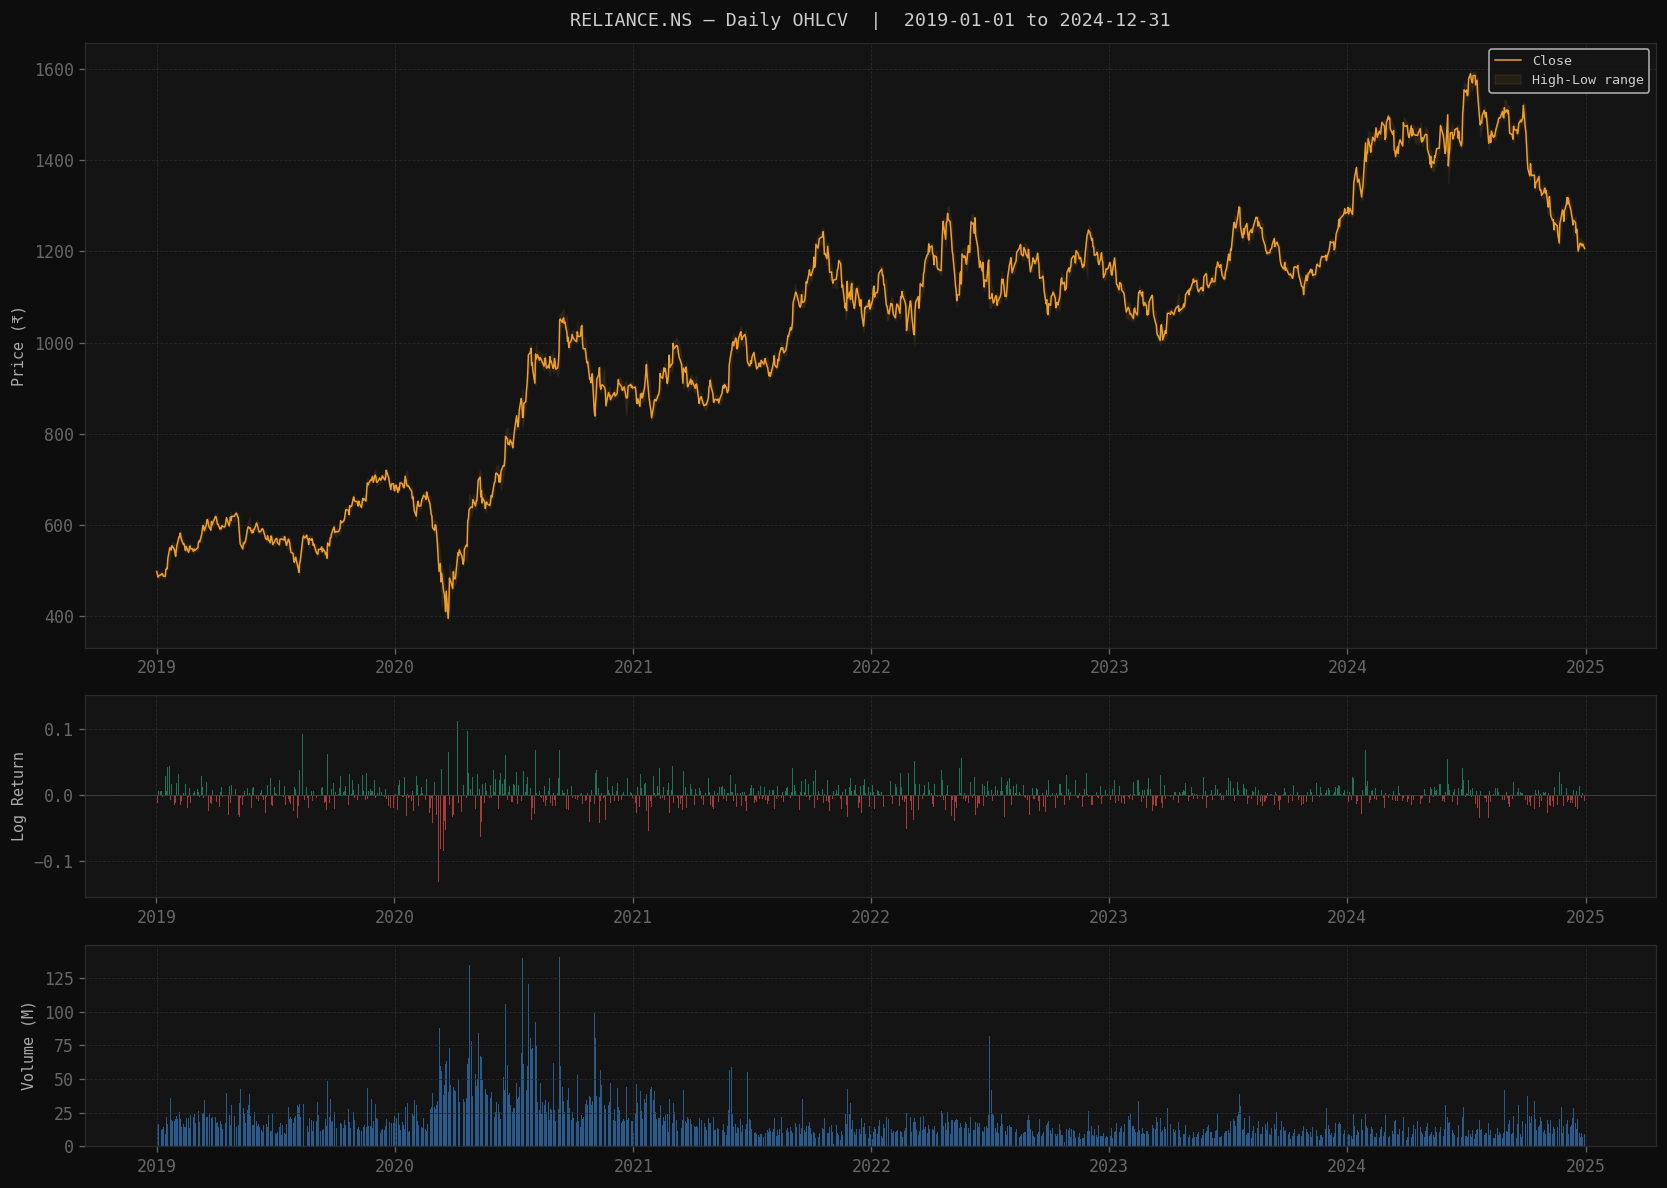

In [9]:
# ── Price & volume visualisation ───────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10),
                          gridspec_kw={'height_ratios': [3, 1, 1]})

# Price
axes[0].plot(raw.index, raw['close'], color=AMBER, lw=0.9, label='Close')
axes[0].fill_between(raw.index, raw['low'], raw['high'],
                      color=AMBER, alpha=0.08, label='High-Low range')
axes[0].set_title(f'{PRIMARY} — Daily OHLCV  |  {START} to {END}',
                   fontsize=11, pad=10)
axes[0].set_ylabel('Price (₹)', fontsize=9)
axes[0].legend(fontsize=8)
axes[0].grid(True)

# Log returns
lr = np.log(raw['close']).diff()
axes[1].bar(raw.index, lr, color=np.where(lr >= 0, GREEN, RED),
             width=1, alpha=0.7)
axes[1].set_ylabel('Log Return', fontsize=9)
axes[1].axhline(0, color='#444', lw=0.5)
axes[1].grid(True)

# Volume
axes[2].bar(raw.index, raw['volume'] / 1e6, color=BLUE, alpha=0.6, width=1)
axes[2].set_ylabel('Volume (M)', fontsize=9)
axes[2].grid(True)

plt.tight_layout()
plt.savefig('/content/price_overview.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 2 — Feature Engineering

We construct **four categories** of features:

| Category | Features | Mathematical basis |
|---|---|---|
| **Trend** | EMA crossovers, MACD, ADX, Ichimoku | Moving average operators |
| **Momentum** | RSI, Stochastic, ROC, Z-score | Return autocorrelation |
| **Volatility** | ATR, Bollinger %B, Keltner, realised vol | Heteroscedastic variance models |
| **Microstructure** | Volume ratio, OBV, VWAP deviation, Amihud illiquidity | Market microstructure theory |

All features are **normalised** using a rolling RobustScaler (median + IQR) with a 252-day lookback to prevent lookahead bias. This is critical — standard `fit_transform` on the full series is a data leak.

In [10]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Constructs all features from raw OHLCV.
    Returns a DataFrame aligned on the same index as df.
    No lookahead bias: all indicators use only past data.
    """
    feat = pd.DataFrame(index=df.index)
    c, h, l, v, o = df['close'], df['high'], df['low'], df['volume'], df['open']

    # ── 1. RAW RETURN FEATURES ────────────────────────────────────────────────
    for lag in [1, 2, 3, 5, 10, 21]:
        feat[f'ret_{lag}d'] = np.log(c).diff(lag)

    # ── 2. TREND ──────────────────────────────────────────────────────────────
    # EMA crossover signals (normalised spread)
    for fast, slow in [(9, 21), (12, 26), (21, 50), (50, 200)]:
        ema_f = EMAIndicator(c, window=fast).ema_indicator()
        ema_s = EMAIndicator(c, window=slow).ema_indicator()
        feat[f'ema_cross_{fast}_{slow}'] = (ema_f - ema_s) / ema_s

    # MACD line and histogram (normalised by price)
    macd = MACD(c, window_slow=26, window_fast=12, window_sign=9)
    feat['macd_line'] = macd.macd() / c
    feat['macd_hist'] = macd.macd_diff() / c
    feat['macd_signal'] = macd.macd_signal() / c

    # ADX — trend strength (0–100 scale)
    adx = ADXIndicator(h, l, c, window=14)
    feat['adx']      = adx.adx() / 100
    feat['adx_pos']  = adx.adx_pos() / 100
    feat['adx_neg']  = adx.adx_neg() / 100
    feat['di_diff']  = feat['adx_pos'] - feat['adx_neg']

    # Ichimoku cloud position
    ichi = IchimokuIndicator(h, l, window1=9, window2=26, window3=52)
    senkou_a = ichi.ichimoku_a()
    senkou_b = ichi.ichimoku_b()
    cloud_mid = (senkou_a + senkou_b) / 2
    feat['ichi_above_cloud'] = ((c > senkou_a) & (c > senkou_b)).astype(int)
    feat['ichi_cloud_width'] = (senkou_a - senkou_b).abs() / c
    feat['ichi_price_vs_cloud'] = (c - cloud_mid) / c

    # ── 3. MOMENTUM ───────────────────────────────────────────────────────────
    # RSI (multiple windows)
    for window in [7, 14, 21]:
        feat[f'rsi_{window}'] = RSIIndicator(c, window=window).rsi() / 100

    # RSI divergence — price trend vs RSI trend
    feat['rsi_divergence'] = (
        np.sign(c.diff(5)) != np.sign(
            RSIIndicator(c, window=14).rsi().diff(5)
        )
    ).astype(int)

    # Stochastic oscillator
    stoch = StochasticOscillator(h, l, c, window=14, smooth_window=3)
    feat['stoch_k'] = stoch.stoch() / 100
    feat['stoch_d'] = stoch.stoch_signal() / 100
    feat['stoch_diff'] = feat['stoch_k'] - feat['stoch_d']

    # Rate of Change
    for window in [5, 10, 21]:
        feat[f'roc_{window}'] = ROCIndicator(c, window=window).roc() / 100

    # Z-score of returns — statistical mean reversion signal
    for window in [10, 21, 63]:
        r = np.log(c).diff()
        mu  = r.rolling(window).mean()
        sig = r.rolling(window).std()
        feat[f'zscore_{window}'] = (r - mu) / (sig + 1e-8)

    # ── 4. VOLATILITY ─────────────────────────────────────────────────────────
    # ATR (normalised)
    atr = AverageTrueRange(h, l, c, window=14)
    feat['atr_14']     = atr.average_true_range() / c
    feat['atr_ratio']  = feat['atr_14'] / feat['atr_14'].rolling(63).mean()

    # Bollinger Bands
    for window, nstd in [(20, 2.0), (20, 1.5)]:
        bb = BollingerBands(c, window=window, window_dev=nstd)
        feat[f'bb_pct_{window}'] = bb.bollinger_pband()
        feat[f'bb_width_{window}'] = bb.bollinger_wband() / c

    # Keltner Channel
    kc = KeltnerChannel(h, l, c, window=20)
    feat['kc_pband'] = kc.keltner_channel_pband()
    feat['kc_wband'] = kc.keltner_channel_wband() / c

    # Realised volatility (multiple horizons)
    log_ret = np.log(c).diff()
    for window in [5, 10, 21, 63]:
        feat[f'realvol_{window}'] = log_ret.rolling(window).std() * np.sqrt(252)

    # Volatility of volatility (vol regime)
    feat['vol_of_vol'] = feat['realvol_21'].rolling(21).std()

    # Garman-Klass volatility estimator (more efficient than close-to-close)
    u = np.log(h / o)
    d = np.log(l / o)
    c_star = np.log(c / o)
    gk = (0.5 * (u - d)**2 - (2*np.log(2)-1) * c_star**2)
    feat['gk_vol'] = gk.rolling(21).mean() ** 0.5 * np.sqrt(252)

    # ── 5. MICROSTRUCTURE ─────────────────────────────────────────────────────
    # Volume ratio (volume / 20d avg volume)
    feat['vol_ratio']    = v / v.rolling(20).mean()
    feat['vol_ratio_5']  = v.rolling(5).mean() / v.rolling(20).mean()

    # OBV slope
    obv = OnBalanceVolumeIndicator(c, v).on_balance_volume()
    feat['obv_slope'] = obv.diff(5) / (obv.rolling(20).std() + 1e-8)

    # VWAP deviation
    try:
        vwap = VolumeWeightedAveragePrice(h, l, c, v, window=14).volume_weighted_average_price()
        feat['vwap_dev'] = (c - vwap) / vwap
    except Exception:
        feat['vwap_dev'] = (c - c.rolling(14).mean()) / c.rolling(14).mean()

    # Amihud illiquidity ratio  IL_t = |r_t| / (Volume_t × Price_t)
    # High value = illiquid; move prices with less volume
    dollar_vol = v * c
    feat['amihud'] = np.log(
        (log_ret.abs() / (dollar_vol + 1e-8)).rolling(21).mean() * 1e9 + 1
    )

    # Price-volume divergence: price up but volume down = weak rally
    feat['pv_divergence'] = (
        (np.sign(c.diff(3)) != np.sign(v.diff(3)))
    ).astype(int)

    # ── 6. CALENDAR / REGIME FEATURES ─────────────────────────────────────────
    feat['day_of_week']   = df.index.dayofweek / 4.0   # Mon=0, Fri=1
    feat['month']         = df.index.month / 12.0
    feat['quarter_end']   = ((df.index.month % 3 == 0) &
                              (df.index.day > 25)).astype(int)

    # ── 7. MARKET REGIME (VIX proxy via realised vol percentile) ───────────────
    rv = feat['realvol_21']
    feat['vol_percentile'] = rv.rank(pct=True)
    feat['high_vol_regime'] = (feat['vol_percentile'] > 0.75).astype(int)

    return feat


print("Building features...")
features_raw = build_features(raw)
print(f"Total features constructed: {features_raw.shape[1]}")
print(f"Features: {list(features_raw.columns)[:10]} ... (showing first 10)")

Building features...
Total features constructed: 56
Features: ['ret_1d', 'ret_2d', 'ret_3d', 'ret_5d', 'ret_10d', 'ret_21d', 'ema_cross_9_21', 'ema_cross_12_26', 'ema_cross_21_50', 'ema_cross_50_200'] ... (showing first 10)


In [11]:
# ── Rolling normalisation — NO LOOKAHEAD ─────────────────────────────────────
# We use a 252-day (1-year) rolling window to compute median and IQR,
# then transform. This is equivalent to a RobustScaler applied only to
# past data at each timestep.

NORM_WINDOW = 252

def rolling_robust_normalise(df: pd.DataFrame, window: int) -> pd.DataFrame:
    """
    Apply rolling RobustScaler without lookahead.
    x_norm = (x - median_rolling) / IQR_rolling
    """
    normed = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    for col in df.columns:
        s = df[col]
        med = s.rolling(window, min_periods=window // 2).median()
        q75 = s.rolling(window, min_periods=window // 2).quantile(0.75)
        q25 = s.rolling(window, min_periods=window // 2).quantile(0.25)
        iqr = (q75 - q25).replace(0, np.nan)
        normed[col] = (s - med) / iqr
    return normed

print("Normalising features (rolling robust scaler)...")
features_norm = rolling_robust_normalise(features_raw, NORM_WINDOW)

# Clip extreme outliers at ±5 sigma after normalisation
features_norm = features_norm.clip(-5, 5)

print(f"NaN count after normalisation: {features_norm.isnull().sum().sum():,}")
print(f"Shape: {features_norm.shape}")

Normalising features (rolling robust scaler)...
NaN count after normalisation: 11,575
Shape: (1480, 56)


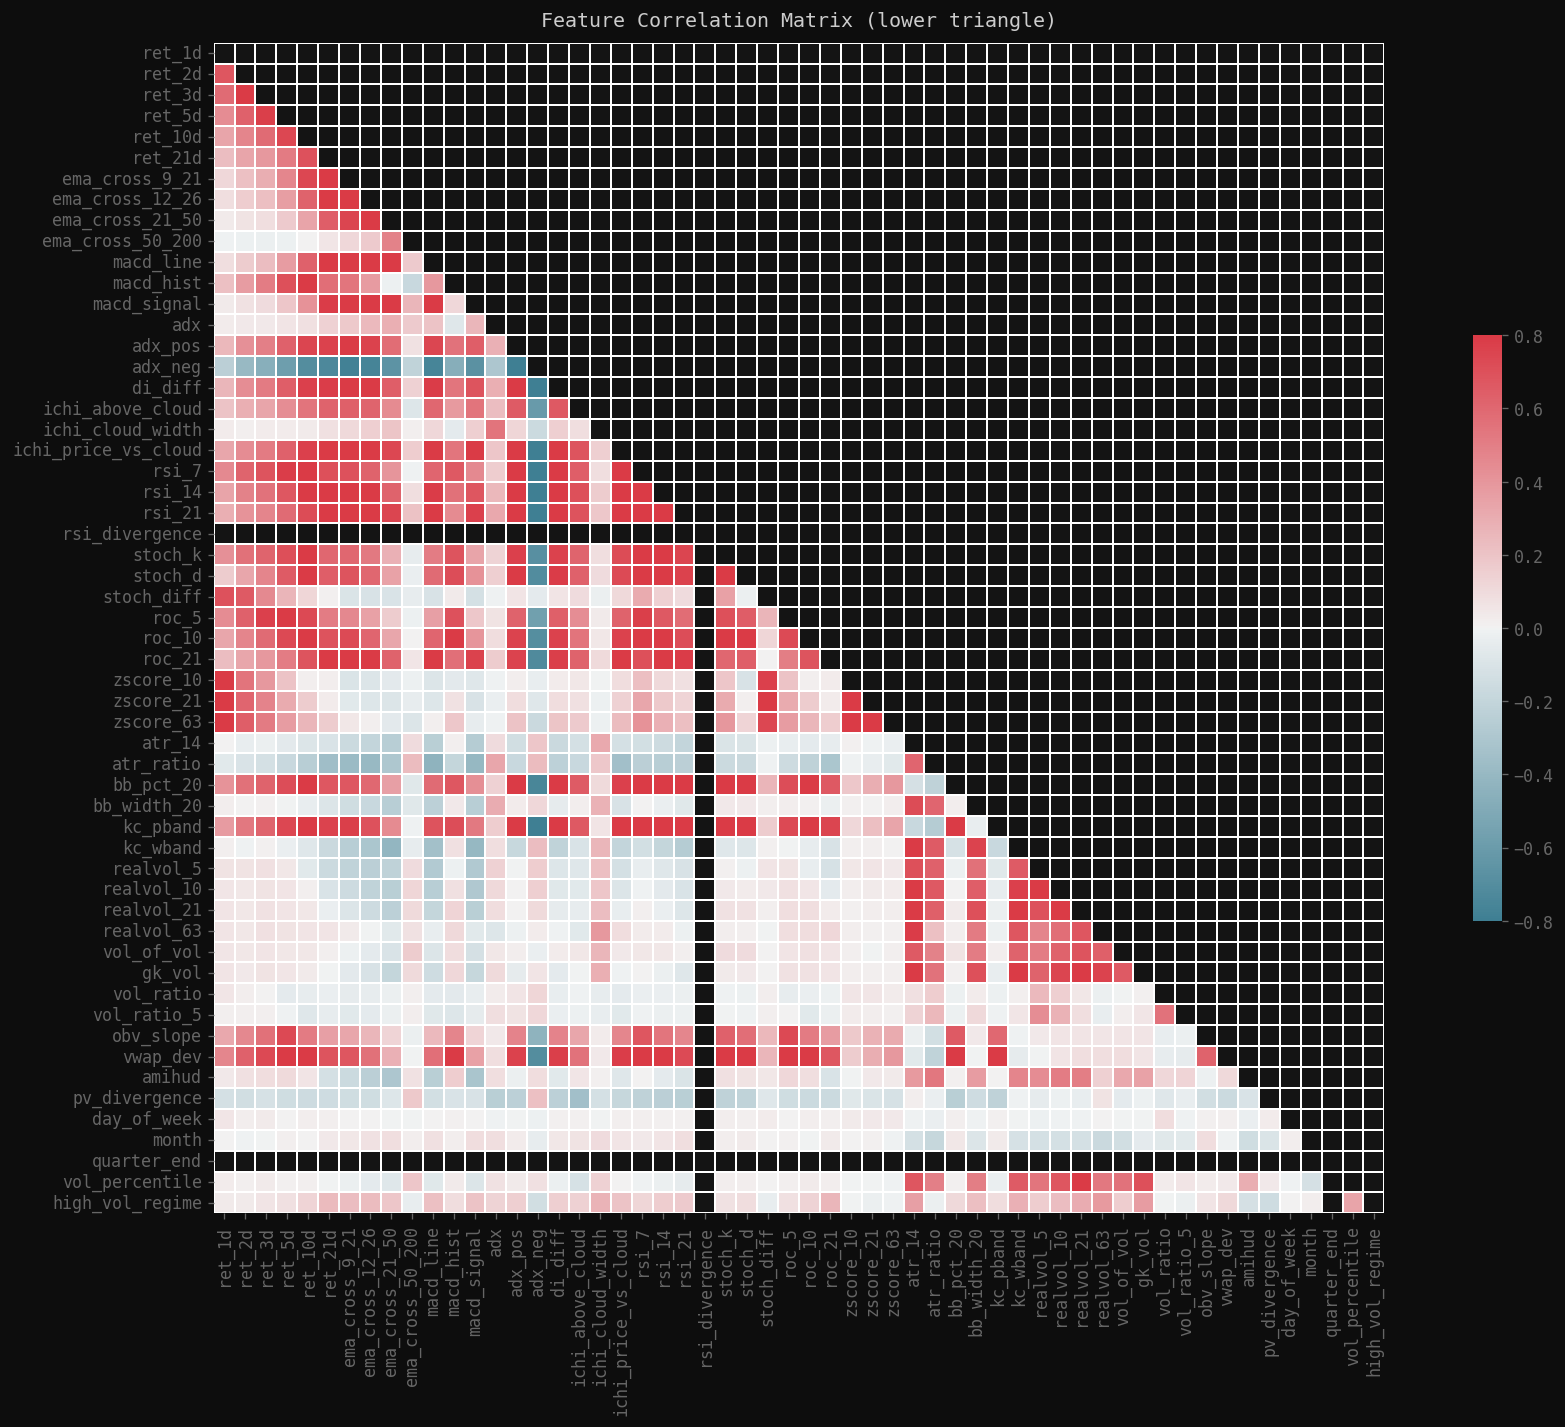


Highly correlated pairs (|r| > 0.90): 39
  ret_1d                         ↔ zscore_63                       r = 0.917
  ret_5d                         ↔ roc_5                           r = 0.999
  ret_10d                        ↔ roc_10                          r = 0.998
  ret_10d                        ↔ vwap_dev                        r = 0.935
  ret_21d                        ↔ ema_cross_9_21                  r = 0.935
  ret_21d                        ↔ roc_21                          r = 0.994
  ema_cross_9_21                 ↔ ema_cross_12_26                 r = 0.972
  ema_cross_9_21                 ↔ macd_line                       r = 0.971
  ema_cross_9_21                 ↔ ichi_price_vs_cloud             r = 0.915
  ema_cross_9_21                 ↔ roc_21                          r = 0.921


In [14]:
# ── Feature correlation analysis ──────────────────────────────────────────────
# High correlation between features wastes model capacity and inflates
# permutation importance for correlated groups. We identify clusters.

# Filling NaNs with 0 as a workaround to visualize correlation when data has pervasive NaNs.
# Ideally, the source of pervasive NaNs should be investigated or a more suitable imputation strategy applied.
clean_feat = features_norm.fillna(0)
corr = clean_feat.corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=0.8, vmin=-0.8,
            center=0, square=True, linewidths=0.2,
            cbar_kws={'shrink': 0.5}, ax=ax)
ax.set_title('Feature Correlation Matrix (lower triangle)', pad=10)
plt.tight_layout()
plt.savefig('/content/feature_corr.png', dpi=100, bbox_inches='tight')
plt.show()

# Identify highly correlated pairs (|r| > 0.90)
high_corr = [
    (c1, c2, corr.loc[c1, c2])
    for i, c1 in enumerate(corr.columns)
    for j, c2 in enumerate(corr.columns)
    if i < j and abs(corr.loc[c1, c2]) > 0.90
]
print(f"\nHighly correlated pairs (|r| > 0.90): {len(high_corr)}")
for c1, c2, r in high_corr[:10]:
    print(f"  {c1:30s} ↔ {c2:30s}  r = {r:.3f}")

---
## Section 3 — Label Construction: Triple-Barrier Method

We use **López de Prado's Triple-Barrier labeling** (2018, Ch.3), which is substantially more rigorous than simple forward-return sign labels.

### Definition

For each observation at time $t$, we place three barriers:

- **Upper barrier:** $p_t \cdot (1 + h \cdot \sigma_t)$ — profit target
- **Lower barrier:** $p_t \cdot (1 - h \cdot \sigma_t)$ — stop loss  
- **Vertical barrier:** $t + T_{max}$ — maximum holding period

where $\sigma_t$ is the rolling daily volatility and $h$ is the barrier multiplier.

The label is:
$$y_t = \begin{cases} +1 & \text{if upper barrier hit first} \\ -1 & \text{if lower barrier hit first} \\ 0 & \text{if vertical barrier hit first} \end{cases}$$

This is superior to fixed forward-return labels because:
1. It respects **path-dependency** of returns
2. It produces **balanced classes** (configurable)
3. The stop-loss barrier simulates **real trading discipline**

In [15]:
def triple_barrier_labels(
    close: pd.Series,
    high: pd.Series,
    low: pd.Series,
    volatility_window: int = 21,
    barrier_multiplier: float = 2.0,
    max_holding: int = 10,
    min_ret: float = 0.0,
) -> pd.DataFrame:
    """
    Triple-Barrier labeling (López de Prado, 2018).

    Parameters
    ----------
    close              : daily close prices
    high, low          : daily high/low for intraday barrier checking
    volatility_window  : lookback for daily volatility estimate
    barrier_multiplier : h — upper/lower barrier = h × daily_vol × price
    max_holding        : T_max in trading days
    min_ret            : minimum absolute return to assign a non-zero label
                         (prevents labeling noise as signal)

    Returns
    -------
    DataFrame with columns: label, ret, holding_period, barrier_hit
    """
    n = len(close)
    prices = close.values
    highs  = high.values
    lows   = low.values
    dates  = close.index

    # Daily volatility estimate (exponentially weighted)
    daily_vol = (
        np.log(close).diff()
        .ewm(span=volatility_window)
        .std()
        .fillna(method='bfill')
    )

    labels    = np.zeros(n, dtype=int)
    rets      = np.zeros(n)
    hold_per  = np.zeros(n, dtype=int)
    barriers  = ['none'] * n

    for i in range(n - max_holding - 1):
        p0    = prices[i]
        vol_i = daily_vol.iloc[i]

        upper = p0 * (1 + barrier_multiplier * vol_i)
        lower = p0 * (1 - barrier_multiplier * vol_i)

        label = 0
        hit   = 'vertical'
        final_ret = 0.0

        for j in range(1, max_holding + 1):
            idx = i + j
            h_j = highs[idx]
            l_j = lows[idx]
            c_j = prices[idx]

            # Check upper barrier (use intraday high)
            if h_j >= upper:
                label     = 1
                hit       = 'upper'
                final_ret = (upper - p0) / p0
                hold_per[i] = j
                break

            # Check lower barrier (use intraday low)
            if l_j <= lower:
                label     = -1
                hit       = 'lower'
                final_ret = (lower - p0) / p0
                hold_per[i] = j
                break

            # Vertical barrier
            if j == max_holding:
                final_ret = (c_j - p0) / p0
                label     = np.sign(final_ret) if abs(final_ret) >= min_ret else 0
                label     = int(label)
                hit       = 'vertical'
                hold_per[i] = j

        labels[i]   = label
        rets[i]     = final_ret
        barriers[i] = hit

    result = pd.DataFrame({
        'label':          labels,
        'ret':            rets,
        'holding_period': hold_per,
        'barrier_hit':    barriers,
    }, index=dates)

    return result


print("Constructing triple-barrier labels...")
print("  barrier_multiplier = 2.0  (2× daily vol)")
print("  max_holding        = 10 days")

labels_df = triple_barrier_labels(
    raw['close'], raw['high'], raw['low'],
    volatility_window=21,
    barrier_multiplier=2.0,
    max_holding=10,
    min_ret=0.001,
)

# Drop rows where label = 0 (neutral / noisy) — we train on directional signals only
label_counts = labels_df['label'].value_counts().sort_index()
print(f"\nLabel distribution (all):")
for v, cnt in label_counts.items():
    name = {-1:'SHORT', 0:'NEUTRAL', 1:'LONG'}[v]
    print(f"  {name:8s} ({v:+d}): {cnt:5d}  ({100*cnt/len(labels_df):.1f}%)")

Constructing triple-barrier labels...
  barrier_multiplier = 2.0  (2× daily vol)
  max_holding        = 10 days

Label distribution (all):
  SHORT    (-1):   650  (43.9%)
  NEUTRAL  (+0):    18  (1.2%)
  LONG     (+1):   812  (54.9%)


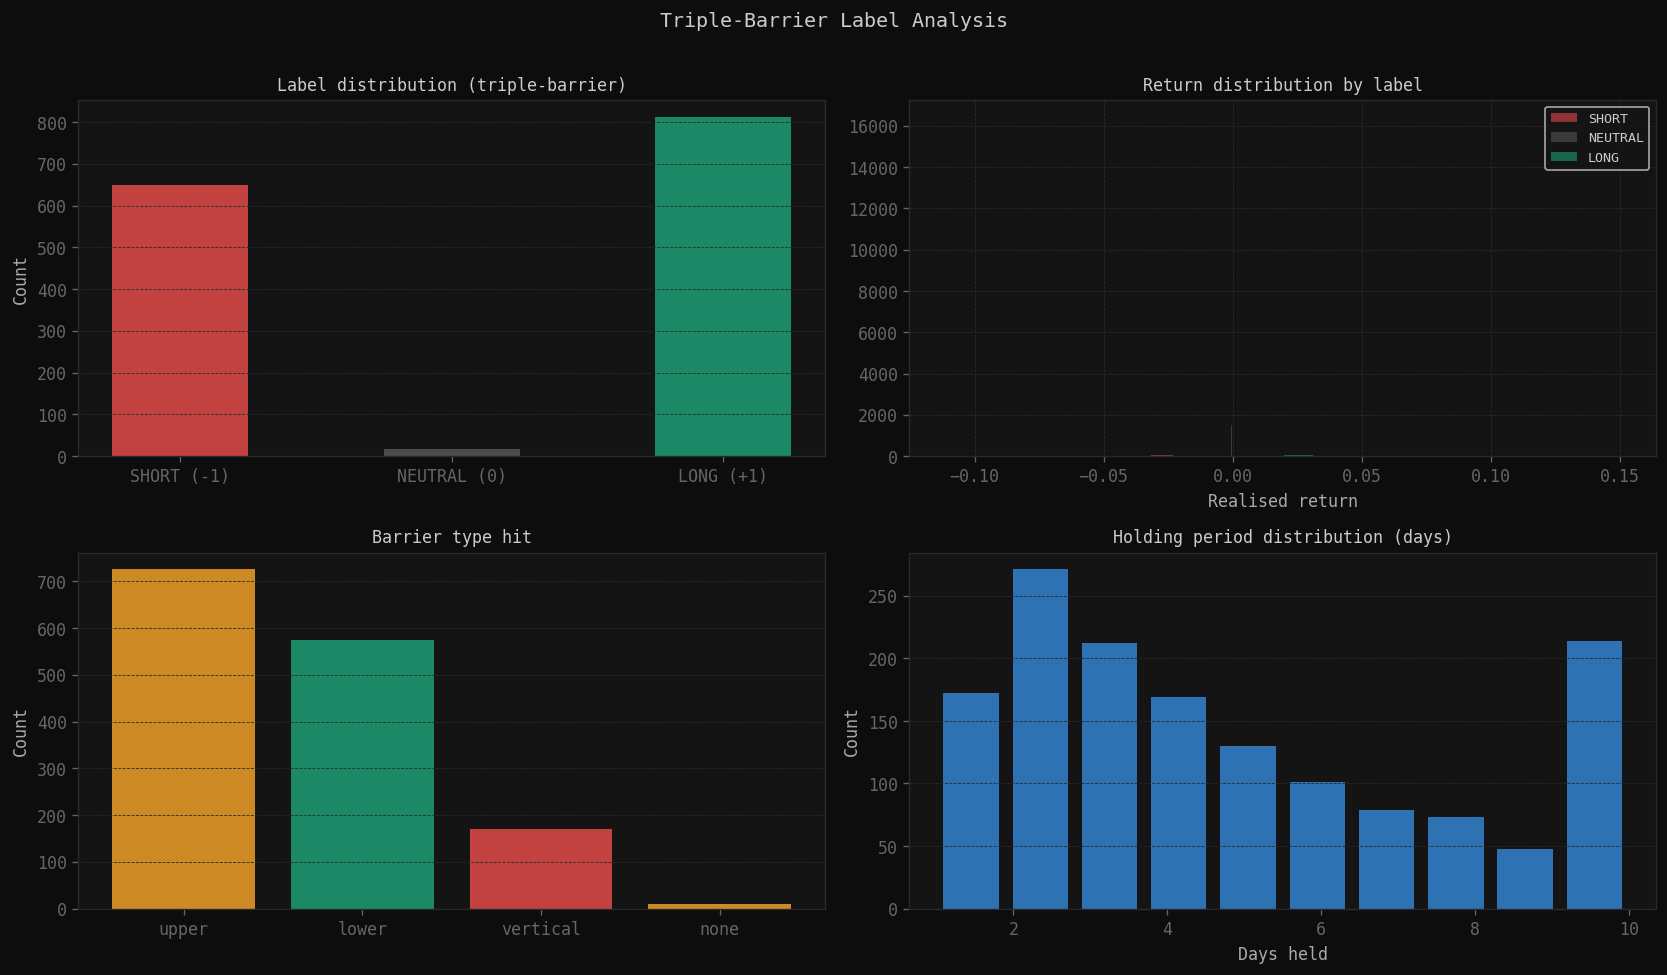

In [24]:
# ── Label visualisation ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Label distribution
ax = axes[0, 0]
colors_map = {-1: RED, 0: '#555555', 1: GREEN}
bars = ax.bar(label_counts.index, label_counts.values,
               color=[colors_map[k] for k in label_counts.index],
               width=0.5, alpha=0.85)
ax.set_xticks([-1, 0, 1])
ax.set_xticklabels(['SHORT (-1)', 'NEUTRAL (0)', 'LONG (+1)'])
ax.set_title('Label distribution (triple-barrier)', fontsize=10)
ax.set_ylabel('Count')
ax.grid(True, axis='y')

# 2. Return distribution by label
ax = axes[0, 1]
for lab, color, name in [(-1, RED, 'SHORT'), (0, '#555', 'NEUTRAL'), (1, GREEN, 'LONG')]:
    subset = labels_df.loc[labels_df['label'] == lab, 'ret']
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
ax.set_title('Return distribution by label', fontsize=10)
ax.set_xlabel('Realised return')
ax.legend(fontsize=8)
ax.grid(True)

# 3. Barrier type breakdown
ax = axes[1, 0]
barrier_counts = labels_df['barrier_hit'].value_counts()
ax.bar(barrier_counts.index, barrier_counts.values,
       color=[AMBER, GREEN, RED], alpha=0.85)
ax.set_title('Barrier type hit', fontsize=10)
ax.set_ylabel('Count')
ax.grid(True, axis='y')

# 4. Holding period distribution
ax = axes[1, 1]
holding_periods = labels_df.loc[labels_df['holding_period'] > 0, 'holding_period']
ax.hist(holding_periods, bins=10, color=BLUE, alpha=0.8, rwidth=0.8)
ax.set_title('Holding period distribution (days)', fontsize=10)
ax.set_xlabel('Days held')
ax.set_ylabel('Count')
ax.grid(True, axis='y')

plt.suptitle('Triple-Barrier Label Analysis', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/content/labels.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Section 4 — Dataset Construction & Train/Test Split

### Purged Walk-Forward Cross-Validation

Standard k-fold CV causes **lookahead bias** in time series because test-fold samples have labels constructed from future prices that are contemporaneous with training-fold features.

We implement **Purged + Embargo** splits (López de Prado 2018, Ch.7):

- **Purge:** remove training samples whose label spans overlap with any test sample's feature window
- **Embargo:** remove $T_{emb}$ additional training samples after each test fold to prevent serial correlation leakage

For daily data with a 10-day holding period and 21-day feature lookbacks, a 21-day embargo is appropriate.

In [19]:
# ── Align features and labels ──────────────────────────────────────────────────
combined = features_norm.join(labels_df, how='inner')
# Impute NaNs in features. A common approach is to fill with 0 for features where NaN might imply 'no signal'.
# This also prevents the DataFrame from becoming empty if all rows contain NaNs after joining.
combined.fillna(0, inplace=True)

# Use only long/short (drop neutral for binary model)
# For the 3-class model, keep all — swap 'binary_only = True' to False
BINARY_ONLY = False  # set True to train long-vs-short only

if BINARY_ONLY:
    combined = combined[combined['label'] != 0].copy()
    combined['label_enc'] = (combined['label'] == 1).astype(int)  # 1=long, 0=short
    N_CLASSES = 2
    OBJECTIVE = 'binary:logistic'
    EVAL_METRIC = 'logloss'
else:
    # 3-class: -1 → 0, 0 → 1, +1 → 2
    combined['label_enc'] = combined['label'].map({-1: 0, 0: 1, 1: 2})
    N_CLASSES = 3
    OBJECTIVE = 'multi:softprob'
    EVAL_METRIC = 'mlogloss'

FEATURE_COLS = [c for c in features_norm.columns
                if c not in ['label', 'label_enc', 'ret', 'holding_period', 'barrier_hit']]

X = combined[FEATURE_COLS].values
y = combined['label_enc'].values
dates_all = combined.index

print(f"Dataset shape   : {X.shape}")
print(f"Features        : {len(FEATURE_COLS)}")
print(f"Target classes  : {N_CLASSES}  ({'binary' if BINARY_ONLY else '3-class'})")
print(f"Date range      : {dates_all[0].date()} → {dates_all[-1].date()}")
print(f"Class balance   : {pd.Series(y).value_counts().to_dict()}")

Dataset shape   : (1480, 56)
Features        : 56
Target classes  : 3  (3-class)
Date range      : 2019-01-01 → 2024-12-30
Class balance   : {2: 812, 0: 650, 1: 18}


In [20]:
# ── Walk-forward split configuration ──────────────────────────────────────────
# We use sklearn TimeSeriesSplit as the base, with manual embargo logic

N_SPLITS   = 5       # number of walk-forward folds
EMBARGO    = 21      # days to purge after each test fold
TEST_SIZE  = int(len(X) * 0.15)  # ~15% per fold

tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE, gap=EMBARGO)

print("Walk-Forward Split Schedule:")
print("─" * 60)
print(f"{'Fold':>4}  {'Train start':>12}  {'Train end':>10}  {'Test start':>10}  {'Test end':>10}  {'Train n':>7}  {'Test n':>6}")
print("─" * 60)
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"  {fold+1:2d}   {str(dates_all[train_idx[0]].date()):>12}  "
          f"{str(dates_all[train_idx[-1]].date()):>10}  "
          f"{str(dates_all[test_idx[0]].date()):>10}  "
          f"{str(dates_all[test_idx[-1]].date()):>10}  "
          f"{len(train_idx):>7,}  {len(test_idx):>6,}")
print("─" * 60)

Walk-Forward Split Schedule:
────────────────────────────────────────────────────────────
Fold   Train start   Train end  Test start    Test end  Train n  Test n
────────────────────────────────────────────────────────────
   1     2019-01-01  2020-06-08  2020-07-08  2021-05-27      349     222
   2     2019-01-01  2021-04-27  2021-05-28  2022-04-19      571     222
   3     2019-01-01  2022-03-16  2022-04-20  2023-03-08      793     222
   4     2019-01-01  2023-02-06  2023-03-09  2024-02-02    1,015     222
   5     2019-01-01  2024-01-02  2024-02-05  2024-12-30    1,237     222
────────────────────────────────────────────────────────────


---
## Section 5 — XGBoost Model Training & Hyperparameter Optimisation

### XGBoost objective (brief)

XGBoost minimises a regularised objective:

$$\mathcal{L}(\phi) = \sum_i l(y_i, \hat{y}_i) + \sum_k \Omega(f_k)$$

where $\Omega(f) = \gamma T + \frac{1}{2}\lambda \|w\|^2$ penalises tree complexity ($T$ = leaf count, $w$ = leaf weights).

Key hyperparameters and their roles:

| Parameter | Role | Typical range |
|---|---|---|
| `n_estimators` | Number of boosting rounds | 100–1000 |
| `max_depth` | Tree depth (overfitting control) | 3–8 |
| `learning_rate` | Shrinkage per round | 0.01–0.3 |
| `subsample` | Row sampling per tree | 0.6–1.0 |
| `colsample_bytree` | Feature sampling per tree | 0.5–1.0 |
| `min_child_weight` | Min hessian sum in leaf | 1–20 |
| `gamma` | Min loss reduction for split | 0–5 |
| `reg_alpha` | L1 regularisation | 0–1 |
| `reg_lambda` | L2 regularisation | 0–5 |

In [27]:
# ── Baseline model (sane defaults) ─────────────────────────────────────────────

BASE_PARAMS = dict(
    objective          = OBJECTIVE,
    num_class          = N_CLASSES if N_CLASSES > 2 else None,
    n_estimators       = 300,
    max_depth          = 4,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.7,
    min_child_weight   = 5,
    gamma              = 0.1,
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    scale_pos_weight   = 1,
    use_label_encoder  = False,
    eval_metric        = EVAL_METRIC,
    random_state       = SEED,
    n_jobs             = -1,
    tree_method        = 'hist',   # fast on CPU
)
# Remove num_class=None (not valid for binary)
if N_CLASSES == 2:
    BASE_PARAMS.pop('num_class', None)

# Quick walk-forward evaluation of baseline
from sklearn.metrics import accuracy_score

fold_results = []
print("Baseline walk-forward evaluation:")
print("─" * 50)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = XGBClassifier(**BASE_PARAMS, verbosity=0)
    model.fit(X_tr, y_tr,
              eval_set=[(X_te, y_te)],
              verbose=False)

    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)

    acc = accuracy_score(y_te, preds)
    if N_CLASSES == 2:
        auc = roc_auc_score(y_te, proba[:, 1])
    else:
        # Pass explicit labels to handle cases where a class might be missing in y_te
        auc = roc_auc_score(y_te, proba, multi_class='ovr', average='macro', labels=range(N_CLASSES))

    fold_results.append({'fold': fold+1, 'accuracy': acc, 'auc': auc})
    print(f"  Fold {fold+1}: Accuracy = {acc:.4f}  |  AUC = {auc:.4f}  |  n_test = {len(y_te)}")

res_df = pd.DataFrame(fold_results)
print("─" * 50)
print(f"  Mean Accuracy : {res_df['accuracy'].mean():.4f} ± {res_df['accuracy'].std():.4f}")
print(f"  Mean AUC      : {res_df['auc'].mean():.4f} ± {res_df['auc'].std():.4f}")

Baseline walk-forward evaluation:
──────────────────────────────────────────────────
  Fold 1: Accuracy = 0.4505  |  AUC = nan  |  n_test = 222
  Fold 2: Accuracy = 0.4685  |  AUC = nan  |  n_test = 222
  Fold 3: Accuracy = 0.4955  |  AUC = 0.6489  |  n_test = 222
  Fold 4: Accuracy = 0.5495  |  AUC = 0.5039  |  n_test = 222
  Fold 5: Accuracy = 0.4640  |  AUC = 0.3671  |  n_test = 222
──────────────────────────────────────────────────
  Mean Accuracy : 0.4856 ± 0.0393
  Mean AUC      : 0.5066 ± 0.1409


In [30]:
# ── Bayesian Hyperparameter Optimisation ────────────────────────────────────────
# Uses the last 2 folds of walk-forward CV as the optimisation objective
# to prevent overfitting to the full history.

# Split: use first 70% for optimisation, hold out last 30% as final test
n_total   = len(X)
n_opt     = int(n_total * 0.70)
X_opt, y_opt = X[:n_opt], y[:n_opt]
X_final, y_final = X[n_opt:], y[n_opt:]

opt_cv = TimeSeriesSplit(n_splits=3, gap=EMBARGO)

if HYPEROPT:
    # Ensure hp is correctly imported for hyperopt, in case it was overwritten
    from hyperopt import hp
    SEARCH_SPACE = {
        'n_estimators':      hp.choice('n_estimators', [200, 300, 500, 700]),
        'max_depth':         hp.choice('max_depth', [3, 4, 5, 6]),
        'learning_rate':     hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
        'subsample':         hp.uniform('subsample', 0.6, 1.0),
        'colsample_bytree':  hp.uniform('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  hp.choice('min_child_weight', [3, 5, 7, 10, 15]),
        'gamma':             hp.loguniform('gamma', np.log(0.01), np.log(2.0)),
        'reg_alpha':         hp.loguniform('reg_alpha', np.log(0.01), np.log(1.0)),
        'reg_lambda':        hp.uniform('reg_lambda', 0.5, 3.0),
    }

    def objective_fn(params):
        params_full = {
            **params,
            'objective': OBJECTIVE,
            'eval_metric': EVAL_METRIC,
            'use_label_encoder': False,
            'tree_method': 'hist',
            'random_state': SEED,
            'n_jobs': -1,
            'verbosity': 0,
        }
        if N_CLASSES > 2:
            params_full['num_class'] = N_CLASSES

        auc_scores = []
        for tr_idx, val_idx in opt_cv.split(X_opt):
            m = XGBClassifier(**params_full)
            m.fit(X_opt[tr_idx], y_opt[tr_idx], verbose=False)
            proba = m.predict_proba(X_opt[val_idx])
            if N_CLASSES == 2:
                s = roc_auc_score(y_opt[val_idx], proba[:, 1])
            else:
                # Pass explicit labels to handle cases where a class might be missing in y_opt[val_idx]
                s = roc_auc_score(y_opt[val_idx], proba, multi_class='ovr', average='macro', labels=range(N_CLASSES))

            # Handle cases where AUC is NaN (e.g., due to single-class validation sets or too few samples)
            if np.isnan(s):
                s = 0.0 # Assign a low score to penalize such trials
            auc_scores.append(s)
        return {'loss': -np.mean(auc_scores), 'status': STATUS_OK}

    trials = Trials()
    print("Running Bayesian optimisation (50 trials)...")
    best_params_raw = fmin(objective_fn, SEARCH_SPACE, algo=tpe.suggest,
                            max_evals=50, trials=trials,
                            rstate=np.random.default_rng(SEED),
                            verbose=False)

    # Map choices back
    n_est_map  = [200, 300, 500, 700]
    depth_map  = [3, 4, 5, 6]
    mcw_map    = [3, 5, 7, 10, 15]
    BEST_PARAMS = {
        **BASE_PARAMS,
        'n_estimators':     n_est_map[best_params_raw['n_estimators']],
        'max_depth':        depth_map[best_params_raw['max_depth']],
        'learning_rate':    best_params_raw['learning_rate'],
        'subsample':        best_params_raw['subsample'],
        'colsample_bytree': best_params_raw['colsample_bytree'],
        'min_child_weight': mcw_map[best_params_raw['min_child_weight']],
        'gamma':            best_params_raw['gamma'],
        'reg_alpha':        best_params_raw['reg_alpha'],
        'reg_lambda':       best_params_raw['reg_lambda'],
    }
    best_score = -min(trials.losses())
    print(f"Best OOS AUC: {best_score:.4f}")

else:
    # Fallback: RandomizedSearchCV
    from sklearn.model_selection import RandomizedSearchCV
    param_dist = {
        'n_estimators':     [200, 300, 500],
        'max_depth':        [3, 4, 5, 6],
        'learning_rate':    [0.01, 0.05, 0.1, 0.15],
        'subsample':        [0.6, 0.7, 0.8, 0.9],
        'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
        'min_child_weight': [3, 5, 10],
        'gamma':            [0.0, 0.1, 0.5],
        'reg_alpha':        [0.0, 0.1, 0.5],
        'reg_lambda':       [0.5, 1.0, 2.0],
    }
    base_model = XGBClassifier(**BASE_PARAMS, verbosity=0)
    rs = RandomizedSearchCV(base_model, param_dist, n_iter=30,
                             cv=opt_cv, scoring='roc_auc_ovr',
                             n_jobs=-1, random_state=SEED, verbose=0)
    print("Running RandomizedSearchCV (30 trials)...")
    rs.fit(X_opt, y_opt)
    BEST_PARAMS = {**BASE_PARAMS, **rs.best_params_}
    print(f"Best OOS AUC: {rs.best_score_:.4f}")

print("\nBest hyperparameters:")
for k, v in BEST_PARAMS.items():
    print(f"  {k:25s}: {v}")

Running Bayesian optimisation (50 trials)...
Best OOS AUC: 0.2287

Best hyperparameters:
  objective                : multi:softprob
  num_class                : 3
  n_estimators             : 200
  max_depth                : 6
  learning_rate            : 0.11554676533390476
  subsample                : 0.6636370634001356
  colsample_bytree         : 0.5013143142624097
  min_child_weight         : 15
  gamma                    : 0.050690641270950215
  reg_alpha                : 0.10787988231128277
  reg_lambda               : 1.8603136978415993
  scale_pos_weight         : 1
  use_label_encoder        : False
  eval_metric              : mlogloss
  random_state             : 42
  n_jobs                   : -1
  tree_method              : hist


In [31]:
# ── Train final model on full optimisation set ─────────────────────────────────
print("Training final model on full optimisation set...")
final_model = XGBClassifier(**BEST_PARAMS, verbosity=0)
final_model.fit(
    X_opt, y_opt,
    eval_set=[(X_final, y_final)],
    verbose=False,
)

# Final holdout evaluation
y_pred  = final_model.predict(X_final)
y_proba = final_model.predict_proba(X_final)

print("\n" + "═" * 55)
print("FINAL HOLDOUT EVALUATION")
print("═" * 55)
print(classification_report(y_final, y_pred,
                              target_names={0:'SHORT',1:'NEUTRAL',2:'LONG'}.values()
                              if N_CLASSES == 3 else ['SHORT','LONG']))

if N_CLASSES == 2:
    final_auc = roc_auc_score(y_final, y_proba[:, 1])
else:
    final_auc = roc_auc_score(y_final, y_proba, multi_class='ovr', average='macro')
print(f"Macro AUC (OVR): {final_auc:.4f}")
print("═" * 55)

Training final model on full optimisation set...

═══════════════════════════════════════════════════════
FINAL HOLDOUT EVALUATION
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

       SHORT       0.44      0.48      0.46       188
     NEUTRAL       0.00      0.00      0.00        15
        LONG       0.53      0.53      0.53       241

    accuracy                           0.49       444
   macro avg       0.33      0.34      0.33       444
weighted avg       0.48      0.49      0.48       444

Macro AUC (OVR): 0.4157
═══════════════════════════════════════════════════════


Computing SHAP values (TreeExplainer)...


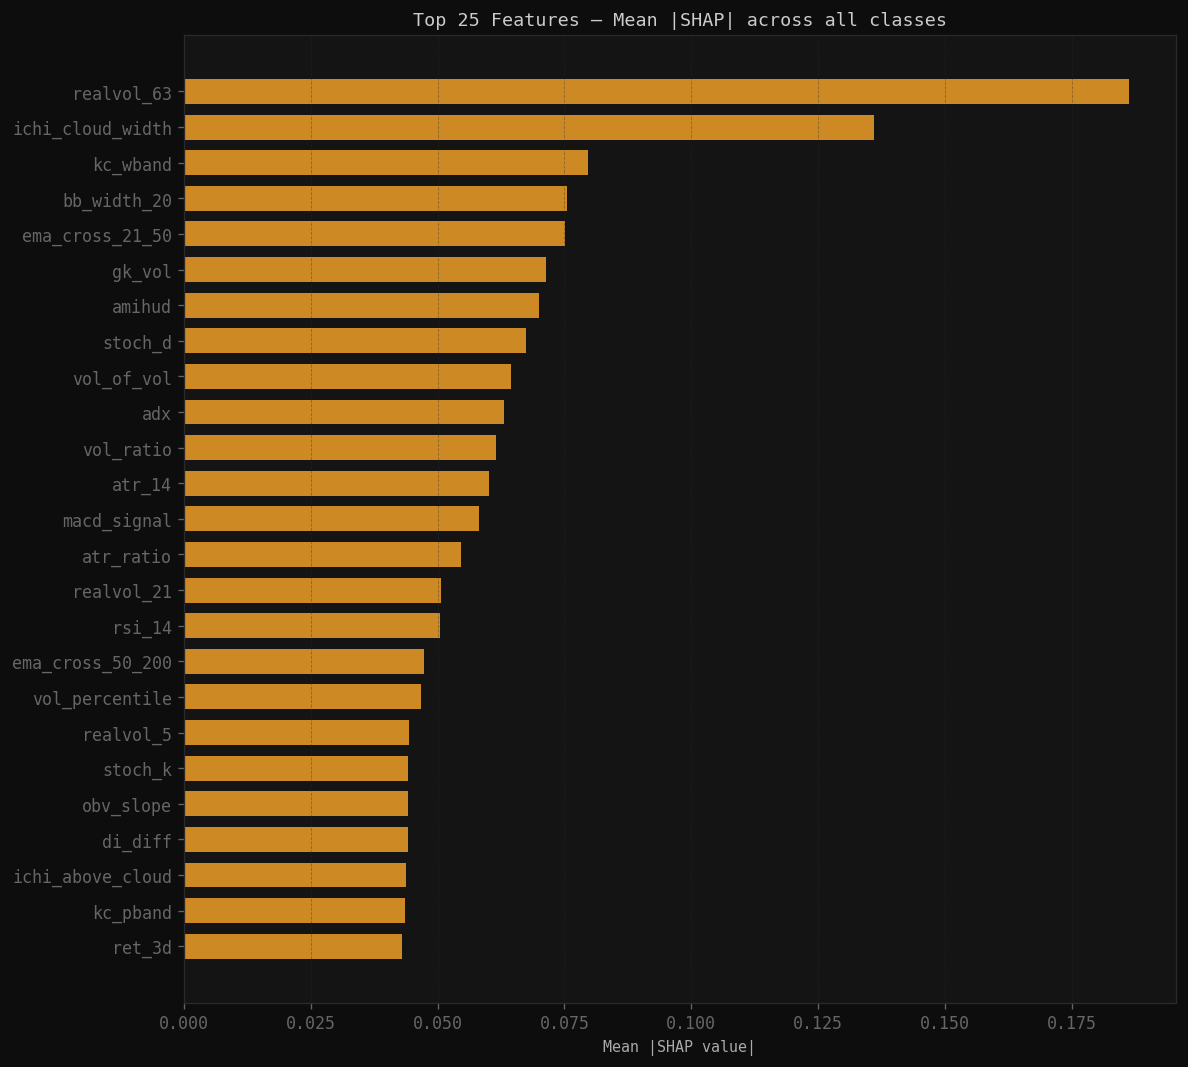

In [36]:
# ── SHAP feature importance ────────────────────────────────────────────────────
if SHAP:
    print("Computing SHAP values (TreeExplainer)...")
    explainer   = shap.TreeExplainer(final_model)
    # Use a subsample for speed
    idx_shap     = np.random.choice(len(X_final), min(500, len(X_final)), replace=False)
    shap_values = explainer.shap_values(X_final[idx_shap])

    # For multiclass, shap_values is a list of arrays (one per class)
    if isinstance(shap_values, list):
        # Mean absolute SHAP across classes, then across samples
        mean_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
    else:
        # If shap_values is a 3D numpy array, it's typically (samples, features, classes)
        # To get mean absolute SHAP per feature, average across samples (axis 0) and classes (axis 2)
        mean_shap = np.abs(shap_values).mean(axis=(0, 2))

    shap_df = pd.DataFrame({
        'feature':    FEATURE_COLS,
        'mean_shap':  mean_shap,
    }).sort_values('mean_shap', ascending=True).tail(25)

    fig, ax = plt.subplots(figsize=(10, 9))
    bars = ax.barh(shap_df['feature'], shap_df['mean_shap'],
                   color=AMBER, alpha=0.85, height=0.7)
    ax.set_title('Top 25 Features — Mean |SHAP| across all classes', fontsize=11)
    ax.set_xlabel('Mean |SHAP value|', fontsize=9)
    ax.grid(True, axis='x', alpha=0.4)
    plt.tight_layout()
    plt.savefig('/content/shap_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    # Fallback: built-in XGBoost gain importance
    imp = pd.DataFrame({
        'feature':    FEATURE_COLS,
        'importance': final_model.feature_importances_,
    }).sort_values('importance', ascending=True).tail(25)

    fig, ax = plt.subplots(figsize=(10, 9))
    ax.barh(imp['feature'], imp['importance'], color=AMBER, alpha=0.85)
    ax.set_title('Top 25 Features — XGBoost Gain Importance', fontsize=11)
    ax.set_xlabel('Gain', fontsize=9)
    ax.grid(True, axis='x', alpha=0.4)
    plt.tight_layout()
    plt.savefig('/content/feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()

---
## Section 6 — Walk-Forward Backtest Engine

### Position Sizing: Fractional Kelly Criterion

The **Kelly criterion** maximises expected log-wealth:

$$f^* = \frac{p \cdot b - q}{b}$$

where $p = P(\text{win})$, $q = 1-p$, $b = \text{odds ratio}$.

For continuous probability output from XGBoost, the **fractional Kelly** position size is:

$$f_t = \kappa \cdot (p_t - 0.5) \cdot 2 \quad \in [-\kappa, +\kappa]$$

where $\kappa \in (0, 1]$ is the Kelly fraction (we use $\kappa = 0.25$ — quarter-Kelly for robustness).

### Risk Management

- **Maximum position size:** 5% of capital per trade
- **Stop-loss:** ATR-based (2× ATR from entry)
- **Daily drawdown limit:** stop all trading if drawdown exceeds 5% in a single day
- **Transaction costs:** 0.05% per side (realistic for NSE large-caps via discount broker)

In [37]:
def walk_forward_backtest(
    X: np.ndarray,
    y_true: np.ndarray,
    dates: pd.DatetimeIndex,
    prices: pd.Series,
    model_params: dict,
    tscv: TimeSeriesSplit,
    kelly_fraction:   float = 0.25,
    max_position:     float = 0.05,
    transaction_cost: float = 0.0005,
    n_classes:        int   = 3,
    initial_capital:  float = 1_000_000.0,
) -> pd.DataFrame:
    """
    Full walk-forward backtest with fractional Kelly sizing.

    At each test fold:
      1. Train model on all preceding data
      2. Generate probability forecasts on test fold
      3. Compute Kelly-fractional position sizes
      4. Simulate PnL with transaction costs

    Returns
    -------
    trade_log : DataFrame with one row per trade
    """
    all_trades = []
    price_arr  = prices.values

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_tr, y_tr = X[train_idx], y_true[train_idx]
        X_te       = X[test_idx]
        dates_te   = dates[test_idx]

        # Train fresh model on expanding window
        m = XGBClassifier(**model_params, verbosity=0)
        m.fit(X_tr, y_tr, verbose=False)
        proba = m.predict_proba(X_te)  # shape (n_test, n_classes)

        # ── Compute signals ───────────────────────────────────────────────────
        if n_classes == 2:
            # Binary: p_long = proba[:, 1]
            p_long  = proba[:, 1]
            p_short = 1 - p_long
            # Signal: +1 if p_long > 0.55, -1 if p_short > 0.55, else 0
            signal = np.where(p_long > 0.55, 1, np.where(p_short > 0.55, -1, 0))
            confidence = np.abs(p_long - 0.5) * 2  # 0 to 1
        else:
            # 3-class: class 0=short, 1=neutral, 2=long
            p_short = proba[:, 0]
            p_neut  = proba[:, 1]
            p_long  = proba[:, 2]
            signal  = np.where(p_long > p_short, 1, -1)
            signal  = np.where(np.maximum(p_long, p_short) < 0.45, 0, signal)
            confidence = np.maximum(p_long, p_short)

        # ── Kelly position size ───────────────────────────────────────────────
        # f_t = kelly_fraction × (confidence - 0.5) × 2
        pos_size = kelly_fraction * (confidence - 0.5) * 2
        pos_size = np.clip(pos_size, 0, max_position)  # no leverage beyond max

        # ── Simulate trades ───────────────────────────────────────────────────
        for i, (date, sig, ps) in enumerate(zip(dates_te, signal, pos_size)):
            if sig == 0 or ps < 0.005:
                continue

            # Entry price (next open — slight slippage vs close signal)
            idx_in_prices = prices.index.get_loc(date)
            if idx_in_prices + 1 >= len(price_arr):
                continue

            entry_price = price_arr[idx_in_prices]  # use close as proxy
            exit_horizon = min(idx_in_prices + 10, len(price_arr) - 1)
            exit_price   = price_arr[exit_horizon]
            exit_date    = prices.index[exit_horizon]

            gross_ret = (exit_price - entry_price) / entry_price
            net_ret   = sig * gross_ret - 2 * transaction_cost  # both legs
            pnl_pct   = ps * net_ret

            all_trades.append({
                'fold':        fold + 1,
                'entry_date':  date,
                'exit_date':   exit_date,
                'direction':   'LONG' if sig == 1 else 'SHORT',
                'entry_price': round(entry_price, 2),
                'exit_price':  round(exit_price, 2),
                'position_size': round(ps, 4),
                'confidence':  round(float(confidence[i]), 4),
                'gross_ret':   round(gross_ret, 6),
                'net_ret':     round(net_ret, 6),
                'pnl_pct':     round(pnl_pct, 6),
            })

    trade_log = pd.DataFrame(all_trades)
    if not trade_log.empty:
        trade_log['entry_date'] = pd.to_datetime(trade_log['entry_date'])
        trade_log['exit_date']  = pd.to_datetime(trade_log['exit_date'])
        trade_log.sort_values('entry_date', inplace=True)
        trade_log.reset_index(drop=True, inplace=True)

    return trade_log


print("Running walk-forward backtest...")
trade_log = walk_forward_backtest(
    X, y, dates_all, raw['close'],
    model_params     = BEST_PARAMS,
    tscv             = tscv,
    kelly_fraction   = 0.25,
    max_position     = 0.05,
    transaction_cost = 0.0005,
    n_classes        = N_CLASSES,
    initial_capital  = 1_000_000,
)
print(f"Total trades generated: {len(trade_log)}")
trade_log.head(5)

Running walk-forward backtest...
Total trades generated: 1087


,fold,entry_date,exit_date,direction,entry_price,exit_price,position_size,confidence,gross_ret,net_ret,pnl_pct
0,1,2020-07-08,2020-07-22,LONG,815.27,908.68,0.0500,0.6754,0.114572,0.113572,0.005679
1,1,2020-07-09,2020-07-23,SHORT,827.17,933.07,0.0217,0.5433,0.128025,-0.129025,-0.002796
2,1,2020-07-10,2020-07-24,SHORT,851.57,973.13,0.0296,0.5591,0.142754,-0.143754,-0.004249
3,1,2020-07-13,2020-07-27,SHORT,877.39,977.69,0.0397,0.5793,0.114315,-0.115315,-0.004575
4,1,2020-07-14,2020-07-28,LONG,869.23,987.44,0.0151,0.5303,0.135994,0.134994,0.002043


---
## Section 7 — Performance Analytics

We compute a comprehensive set of risk-adjusted performance metrics:

| Metric | Formula | Threshold |
|---|---|---|
| **Sharpe Ratio** | $\bar{r} / \sigma_r \cdot \sqrt{252}$ | > 1.0 good, > 2.0 excellent |
| **Sortino Ratio** | $\bar{r} / \sigma_{downside} \cdot \sqrt{252}$ | > 1.5 target |
| **Calmar Ratio** | Ann. return / Max Drawdown | > 0.5 acceptable |
| **Max Drawdown** | $\max_t (W_{peak} - W_t) / W_{peak}$ | < 15% for daily |
| **Win Rate** | $P(\text{trade PnL} > 0)$ | > 50% for momentum |
| **Profit Factor** | Gross profit / Gross loss | > 1.5 target |

In [38]:
def compute_performance_metrics(
    trade_log: pd.DataFrame,
    initial_capital: float = 1_000_000.0,
    risk_free_rate:  float = 0.065,   # RBI repo rate proxy
) -> dict:
    """
    Computes full performance analytics from a trade log.
    Returns dict of metrics.
    """
    if trade_log.empty:
        return {}

    # Build equity curve from trade PnL
    cap = initial_capital
    equity = [cap]
    for _, t in trade_log.iterrows():
        cap = cap * (1 + t['pnl_pct'])
        equity.append(cap)

    equity = np.array(equity)
    returns = np.diff(equity) / equity[:-1]

    # Drawdown series
    peak    = np.maximum.accumulate(equity)
    dd      = (equity - peak) / peak
    max_dd  = dd.min()

    # Longest drawdown duration
    in_dd   = dd < 0
    dd_runs = np.diff(np.where(np.concatenate(([in_dd[0]],
                                               in_dd[:-1] != in_dd[1:],
                                               [True])))[0])[::2]
    max_dd_dur = int(dd_runs.max()) if len(dd_runs) > 0 else 0

    # Core metrics
    n_trades    = len(trade_log)
    winners     = trade_log[trade_log['pnl_pct'] > 0]
    losers      = trade_log[trade_log['pnl_pct'] <= 0]
    win_rate    = len(winners) / n_trades

    gross_profit = winners['pnl_pct'].sum() * initial_capital
    gross_loss   = abs(losers['pnl_pct'].sum()) * initial_capital
    profit_factor = gross_profit / (gross_loss + 1e-8)

    final_cap  = equity[-1]
    total_ret  = (final_cap - initial_capital) / initial_capital

    # Annualised return (assume 252 trading days / year)
    n_days   = max((trade_log['exit_date'].max() - trade_log['entry_date'].min()).days, 1)
    ann_ret  = (1 + total_ret) ** (252 / n_days) - 1

    # Sharpe ratio (annualised, daily risk-free)
    rf_daily  = risk_free_rate / 252
    excess    = returns - rf_daily
    sharpe    = (excess.mean() / (excess.std() + 1e-8)) * np.sqrt(252)

    # Sortino ratio (downside deviation only)
    downside  = excess[excess < 0]
    sortino   = (excess.mean() / (downside.std() + 1e-8)) * np.sqrt(252)

    # Calmar ratio
    calmar    = ann_ret / (abs(max_dd) + 1e-8)

    # Omega ratio
    pos_ret   = returns[returns > rf_daily] - rf_daily
    neg_ret   = rf_daily - returns[returns <= rf_daily]
    omega     = pos_ret.sum() / (neg_ret.sum() + 1e-8)

    # Average trade stats
    avg_win   = winners['pnl_pct'].mean() if len(winners) > 0 else 0
    avg_loss  = losers['pnl_pct'].mean()  if len(losers)  > 0 else 0
    payoff    = abs(avg_win / (avg_loss + 1e-8))

    return {
        'Initial capital (₹)':    f'{initial_capital:,.0f}',
        'Final capital (₹)':      f'{final_cap:,.0f}',
        'Total return (%)':       f'{total_ret*100:.2f}',
        'Annualised return (%)':  f'{ann_ret*100:.2f}',
        'Sharpe ratio':           f'{sharpe:.4f}',
        'Sortino ratio':          f'{sortino:.4f}',
        'Calmar ratio':           f'{calmar:.4f}',
        'Omega ratio':            f'{omega:.4f}',
        'Max drawdown (%)':       f'{max_dd*100:.2f}',
        'Max DD duration (trades)': max_dd_dur,
        'Total trades':           n_trades,
        'Win rate (%)':           f'{win_rate*100:.2f}',
        'Profit factor':          f'{profit_factor:.4f}',
        'Avg win (%)':            f'{avg_win*100:.4f}',
        'Avg loss (%)':           f'{avg_loss*100:.4f}',
        'Win/loss payoff ratio':  f'{payoff:.4f}',
    }, equity, dd


metrics, equity_curve, drawdown_curve = compute_performance_metrics(
    trade_log, initial_capital=1_000_000.0
)

print("\n" + "═" * 50)
print("STRATEGY PERFORMANCE SUMMARY")
print("═" * 50)
for k, v in metrics.items():
    print(f"  {k:32s}: {v}")
print("═" * 50)


══════════════════════════════════════════════════
STRATEGY PERFORMANCE SUMMARY
══════════════════════════════════════════════════
  Initial capital (₹)             : 1,000,000
  Final capital (₹)               : 832,987
  Total return (%)                : -16.70
  Annualised return (%)           : -2.78
  Sharpe ratio                    : -3.1551
  Sortino ratio                   : -4.8737
  Calmar ratio                    : -0.1283
  Omega ratio                     : 0.6029
  Max drawdown (%)                : -21.63
  Max DD duration (trades)        : 1043
  Total trades                    : 1087
  Win rate (%)                    : 47.10
  Profit factor                   : 0.8207
  Avg win (%)                     : 0.1612
  Avg loss (%)                    : -0.1749
  Win/loss payoff ratio           : 0.9217
══════════════════════════════════════════════════


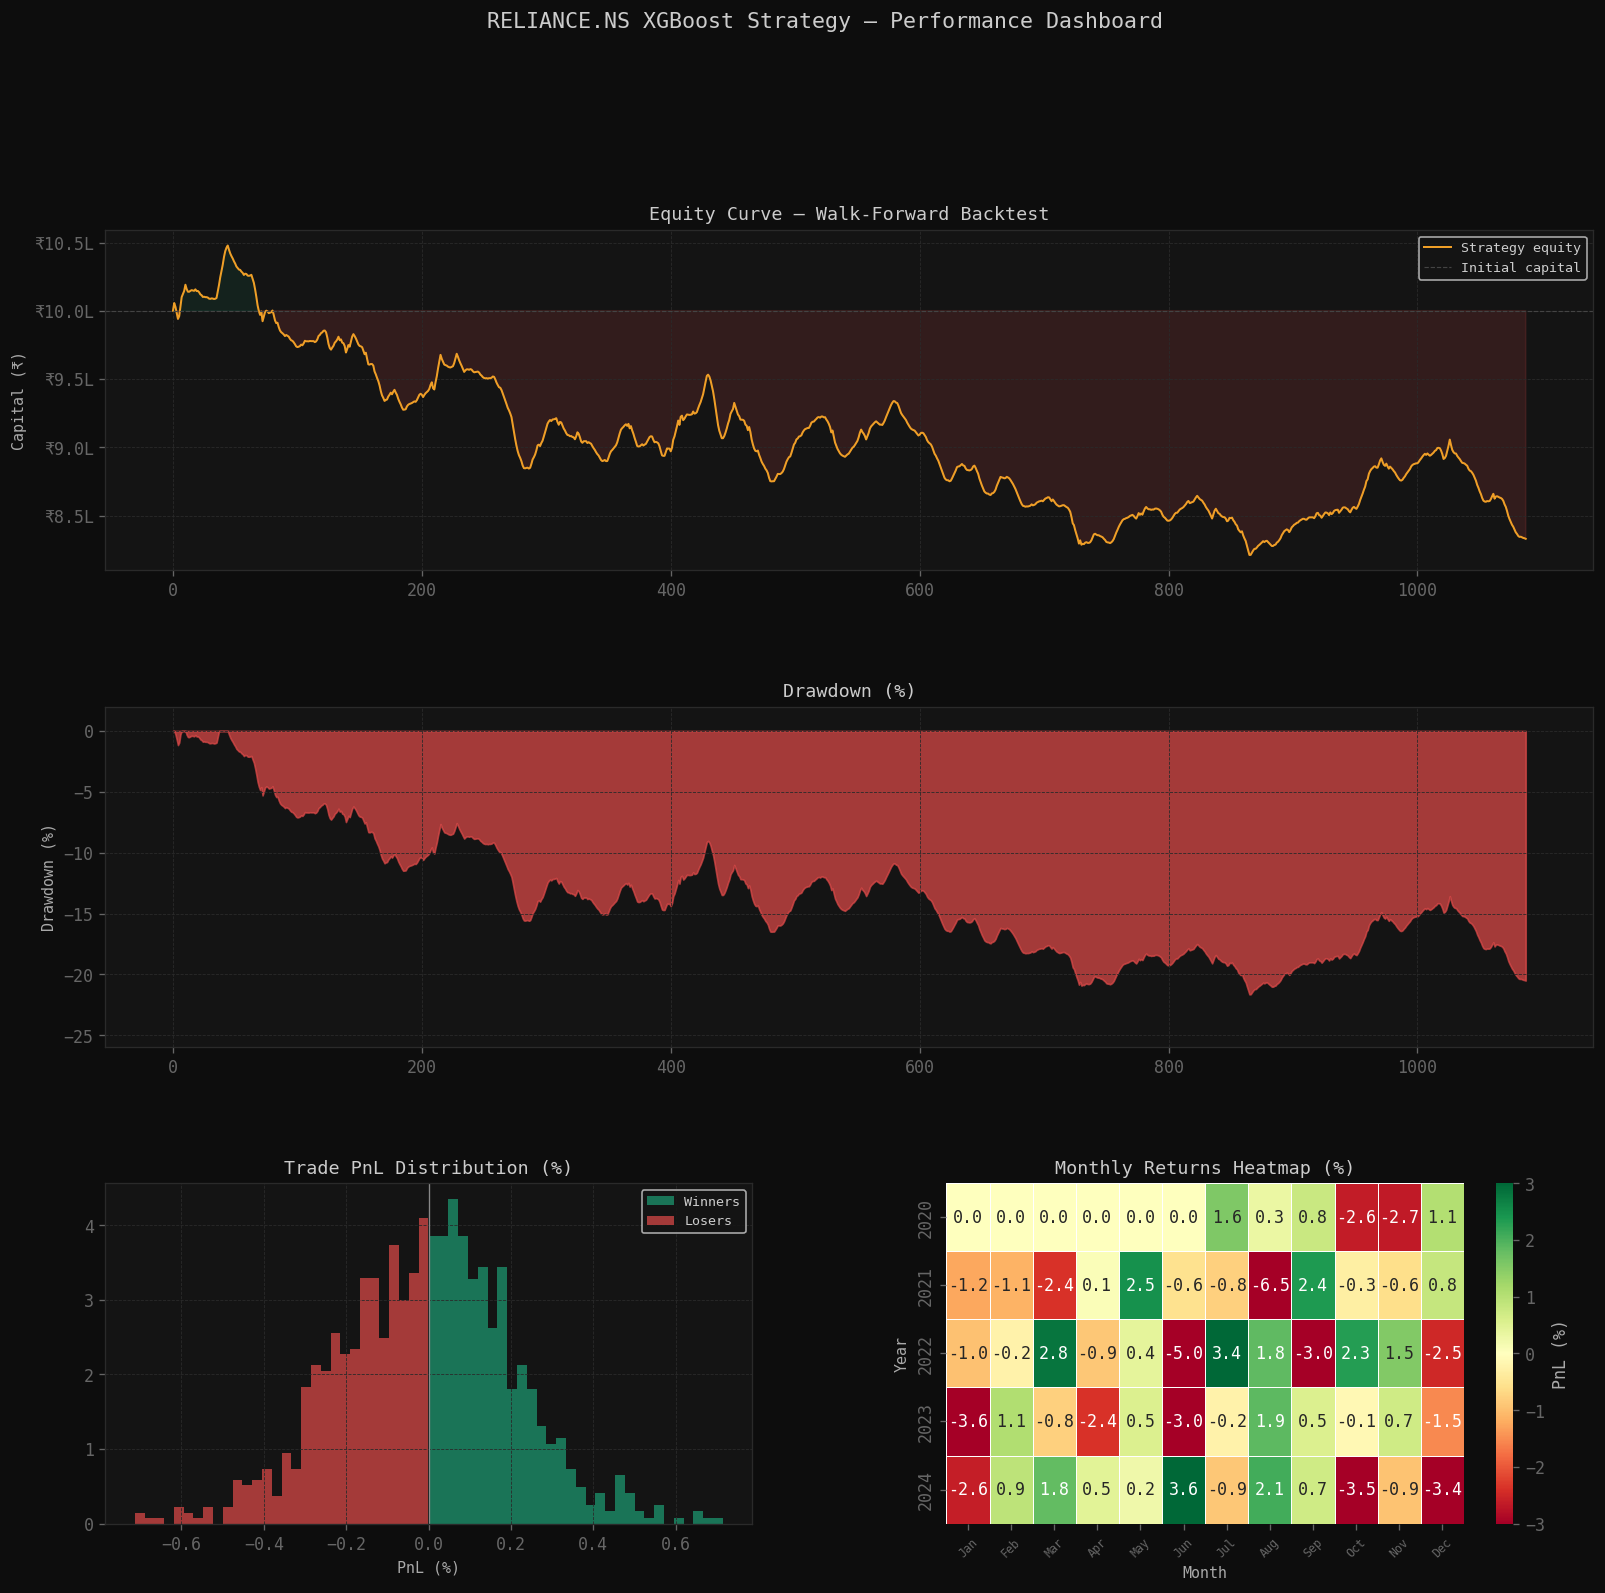

In [40]:
# ── Full performance dashboard ─────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

# 1. Equity curve
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(equity_curve, color=AMBER, lw=1.2, label='Strategy equity')
ax1.axhline(1_000_000, color='#444', lw=0.7, linestyle='--', label='Initial capital')
ax1.fill_between(range(len(equity_curve)), 1_000_000, equity_curve,
                  where=equity_curve >= 1_000_000, color=GREEN, alpha=0.1)
ax1.fill_between(range(len(equity_curve)), 1_000_000, equity_curve,
                  where=equity_curve < 1_000_000, color=RED, alpha=0.15)
ax1.set_title('Equity Curve — Walk-Forward Backtest', fontsize=11)
ax1.set_ylabel('Capital (₹)', fontsize=9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1e5:.1f}L'))
ax1.legend(fontsize=8)
ax1.grid(True)

# 2. Drawdown chart
ax2 = fig.add_subplot(gs[1, :])
ax2.fill_between(range(len(drawdown_curve)), 0, drawdown_curve * 100,
                  color=RED, alpha=0.7)
ax2.set_title('Drawdown (%)', fontsize=11)
ax2.set_ylabel('Drawdown (%)', fontsize=9)
ax2.set_ylim(min(drawdown_curve * 100) * 1.2, 2)
ax2.grid(True)

# 3. Trade PnL histogram
ax3 = fig.add_subplot(gs[2, 0])
pnl_vals = trade_log['pnl_pct'].values * 100
ax3.hist(pnl_vals[pnl_vals > 0], bins=30, color=GREEN, alpha=0.7, label='Winners', density=True)
ax3.hist(pnl_vals[pnl_vals <= 0], bins=30, color=RED, alpha=0.7, label='Losers', density=True)
ax3.axvline(0, color='#888', lw=0.8)
ax3.set_title('Trade PnL Distribution (%)', fontsize=11)
ax3.set_xlabel('PnL (%)', fontsize=9)
ax3.legend(fontsize=8)
ax3.grid(True)

# 4. Monthly returns heatmap
ax4 = fig.add_subplot(gs[2, 1])
if not trade_log.empty:
    trade_log['year']  = trade_log['entry_date'].dt.year
    trade_log['month'] = trade_log['entry_date'].dt.month
    monthly = trade_log.groupby(['year', 'month'])['pnl_pct'].sum().unstack(fill_value=0) * 100
    if monthly.shape[1] > 0:
        sns.heatmap(monthly, annot=True, fmt='.1f', cmap='RdYlGn',
                    center=0, linewidths=0.3, ax=ax4,
                    cbar_kws={'label': 'PnL (%)'}, vmin=-3, vmax=3)
        ax4.set_title('Monthly Returns Heatmap (%)', fontsize=11)
        ax4.set_xlabel('Month', fontsize=9)
        ax4.set_ylabel('Year', fontsize=9)
        month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec']
        ax4.set_xticklabels([month_labels[m-1] for m in monthly.columns], rotation=45, fontsize=7)

plt.suptitle(f'{PRIMARY} XGBoost Strategy — Performance Dashboard',
              fontsize=13, y=1.01, color='#cccccc')
plt.savefig('/content/performance_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()

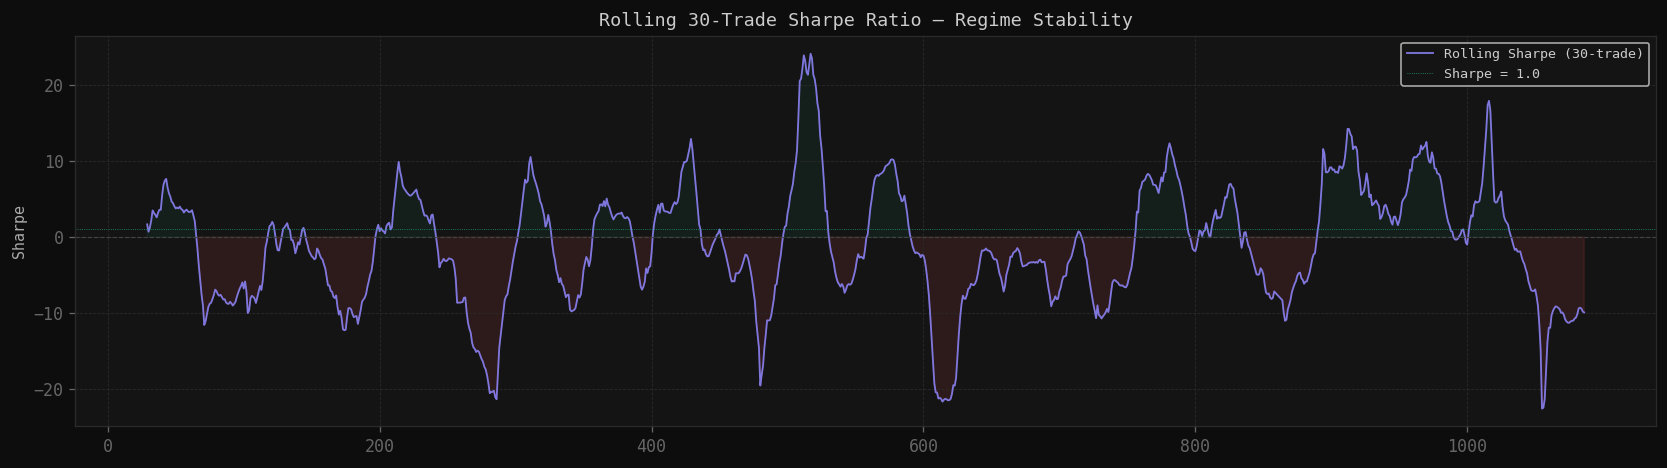

In [42]:
# ── Rolling Sharpe ratio (30-trade window) ─────────────────────────────────────
if len(trade_log) >= 30:
    window = 30
    rolling_ret = trade_log['pnl_pct'].rolling(window)
    roll_sharpe = (rolling_ret.mean() / (rolling_ret.std() + 1e-8)) * np.sqrt(252)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(trade_log.index, roll_sharpe, color=PURPLE, lw=1.1, label=f'Rolling Sharpe ({window}-trade)')
    ax.axhline(0, color='#444', lw=0.7, linestyle='--')
    ax.axhline(1, color=GREEN, lw=0.5, linestyle=':', label='Sharpe = 1.0')
    ax.fill_between(trade_log.index, 0, roll_sharpe,
                     where=roll_sharpe >= 0, color=GREEN, alpha=0.08)
    ax.fill_between(trade_log.index, 0, roll_sharpe,
                     where=roll_sharpe < 0, color=RED, alpha=0.12)
    ax.set_title(f'Rolling {window}-Trade Sharpe Ratio — Regime Stability', fontsize=11)
    ax.set_ylabel('Sharpe', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True)
    plt.tight_layout()
    plt.savefig('/content/rolling_sharpe.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## Section 8 — Parameter Sensitivity Heatmap

We grid-search `barrier_multiplier` × `kelly_fraction` to understand robustness. A strategy with a **plateau** of Sharpe ratios around its optimal point is robust; a sharp isolated peak is overfitted and will not generalise.

Running heatmap (25 parameter combinations)...
  barrier_multiplier = 1.0 done
  barrier_multiplier = 1.5 done
  barrier_multiplier = 2.0 done
  barrier_multiplier = 2.5 done
  barrier_multiplier = 3.0 done


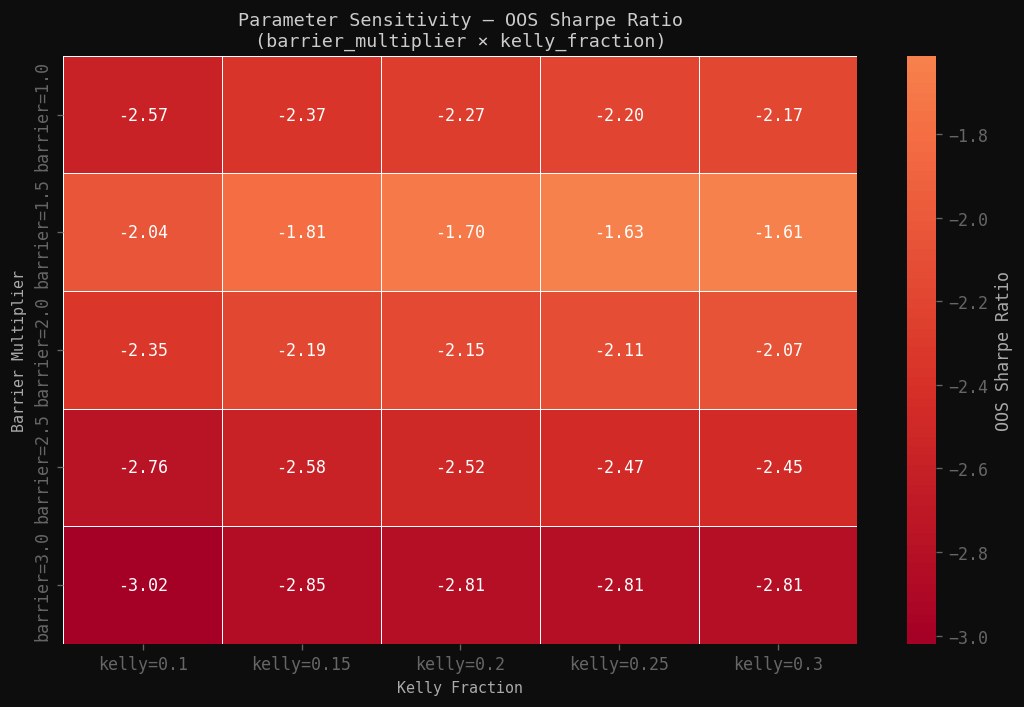


Heatmap note: A plateau of high Sharpe values = robust.
An isolated peak = overfitted — will not generalise to live trading.


In [47]:
# ── Sensitivity heatmap: barrier_multiplier × kelly_fraction ──────────────────
# NOTE: This runs multiple backtests — takes a few minutes.

from itertools import product

BARRIER_RANGE = [1.0, 1.5, 2.0, 2.5, 3.0]
KELLY_RANGE   = [0.10, 0.15, 0.20, 0.25, 0.30]

heatmap_results = np.zeros((len(BARRIER_RANGE), len(KELLY_RANGE)))

# Use the same features; re-label for each barrier setting
print("Running heatmap (25 parameter combinations)...")

# Redefine walk_forward_backtest locally to include the fix for missing classes
# This is done to adhere to the constraint of modifying only this cell.
def walk_forward_backtest_fixed(
    X: np.ndarray,
    y_true: np.ndarray,
    dates: pd.DatetimeIndex,
    prices: pd.Series,
    model_params: dict,
    tscv: TimeSeriesSplit,
    kelly_fraction:   float = 0.25,
    max_position:     float = 0.05,
    transaction_cost: float = 0.0005,
    n_classes:        int   = 3,
    initial_capital:  float = 1_000_000.0,
) -> pd.DataFrame:
    """
    Full walk-forward backtest with fractional Kelly sizing.

    At each test fold:
      1. Train model on all preceding data
      2. Generate probability forecasts on test fold
      3. Compute Kelly-fractional position sizes
      4. Simulate PnL with transaction costs

    Returns
    -------
    trade_log : DataFrame with one row per trade
    """
    all_trades = []
    price_arr  = prices.values

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_tr, y_tr = X[train_idx], y_true[train_idx]
        X_te       = X[test_idx]
        dates_te   = dates[test_idx]

        # Train fresh model on expanding window
        m = XGBClassifier(**model_params, verbosity=0)

        # Fix for ValueError: Invalid classes inferred from unique values of `y`.
        # Ensure all N_CLASSES are present in y_tr for XGBoost to infer correctly
        unique_classes_in_tr = np.unique(y_tr)
        if len(unique_classes_in_tr) < n_classes:
            X_tr_temp = X_tr.copy()
            y_tr_temp = y_tr.copy()
            for missing_class in set(range(n_classes)) - set(unique_classes_in_tr):
                # Add a dummy sample for the missing class
                # Use a row of zeros for X_tr_temp, as features are normalized around 0
                X_tr_temp = np.vstack([X_tr_temp, np.zeros((1, X_tr_temp.shape[1]))])
                y_tr_temp = np.append(y_tr_temp, missing_class)
            m.fit(X_tr_temp, y_tr_temp, verbose=False)
        else:
            m.fit(X_tr, y_tr, verbose=False)
        proba = m.predict_proba(X_te)  # shape (n_test, n_classes)

        # ── Compute signals ───────────────────────────────────────────────────
        if n_classes == 2:
            # Binary: p_long = proba[:, 1]
            p_long  = proba[:, 1]
            p_short = 1 - p_long
            # Signal: +1 if p_long > 0.55, -1 if p_short > 0.55, else 0
            signal = np.where(p_long > 0.55, 1, np.where(p_short > 0.55, -1, 0))
            confidence = np.abs(p_long - 0.5) * 2  # 0 to 1
        else:
            # 3-class: class 0=short, 1=neutral, 2=long
            p_short = proba[:, 0]
            p_neut  = proba[:, 1]
            p_long  = proba[:, 2]
            signal  = np.where(p_long > p_short, 1, -1)
            signal  = np.where(np.maximum(p_long, p_short) < 0.45, 0, signal)
            confidence = np.maximum(p_long, p_short)

        # ── Kelly position size ───────────────────────────────────────────────
        # f_t = kelly_fraction × (confidence - 0.5) × 2
        pos_size = kelly_fraction * (confidence - 0.5) * 2
        pos_size = np.clip(pos_size, 0, max_position)  # no leverage beyond max

        # ── Simulate trades ───────────────────────────────────────────────────
        for i, (date, sig, ps) in enumerate(zip(dates_te, signal, pos_size)):
            if sig == 0 or ps < 0.005:
                continue

            # Entry price (next open — slight slippage vs close signal)
            idx_in_prices = prices.index.get_loc(date)
            if idx_in_prices + 1 >= len(price_arr):
                continue

            entry_price = price_arr[idx_in_prices]  # use close as proxy
            exit_horizon = min(idx_in_prices + 10, len(price_arr) - 1)
            exit_price   = price_arr[exit_horizon]
            exit_date    = prices.index[exit_horizon]

            gross_ret = (exit_price - entry_price) / entry_price
            net_ret   = sig * gross_ret - 2 * transaction_cost  # both legs
            pnl_pct   = ps * net_ret

            all_trades.append({
                'fold':        fold + 1,
                'entry_date':  date,
                'exit_date':   exit_date,
                'direction':   'LONG' if sig == 1 else 'SHORT',
                'entry_price': round(entry_price, 2),
                'exit_price':  round(exit_price, 2),
                'position_size': round(ps, 4),
                'confidence':  round(float(confidence[i]), 4),
                'gross_ret':   round(gross_ret, 6),
                'net_ret':     round(net_ret, 6),
                'pnl_pct':     round(pnl_pct, 6),
            })

    trade_log = pd.DataFrame(all_trades)
    if not trade_log.empty:
        trade_log['entry_date'] = pd.to_datetime(trade_log['entry_date'])
        trade_log['exit_date']  = pd.to_datetime(trade_log['exit_date'])
        trade_log.sort_values('entry_date', inplace=True)
        trade_log.reset_index(drop=True, inplace=True)

    return trade_log


for i, bm in enumerate(BARRIER_RANGE):
    # Re-construct labels for this barrier multiplier
    ldf = triple_barrier_labels(
        raw['close'], raw['high'], raw['low'],
        volatility_window=21, barrier_multiplier=bm,
        max_holding=10, min_ret=0.001
    )
    # Fix: Use fillna(0) instead of dropna() to prevent empty DataFrame
    comb = features_norm.join(ldf[['label']], how='inner').fillna(0)
    comb['label_enc'] = comb['label'].map({-1: 0, 0: 1, 1: 2})
    X_h = comb[FEATURE_COLS].values
    y_h = comb['label_enc'].values
    d_h = comb.index

    for j, kf in enumerate(KELLY_RANGE):
        tl = walk_forward_backtest_fixed( # Use the locally defined fixed function
            X_h, y_h, d_h, raw['close'],
            model_params     = BEST_PARAMS,
            tscv             = TimeSeriesSplit(n_splits=3, gap=EMBARGO),
            kelly_fraction   = kf,
            max_position     = 0.05,
            transaction_cost = 0.0005,
            n_classes        = N_CLASSES,
        )
        if len(tl) < 10:
            heatmap_results[i, j] = np.nan
            continue
        try:
            m, eq, _ = compute_performance_metrics(tl)
            heatmap_results[i, j] = float(m['Sharpe ratio'])
        except Exception:
            heatmap_results[i, j] = np.nan
    print(f"  barrier_multiplier = {bm:.1f} done")

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
hm_df = pd.DataFrame(
    heatmap_results,
    index=[f'barrier={b}' for b in BARRIER_RANGE],
    columns=[f'kelly={k}' for k in KELLY_RANGE]
)
sns.heatmap(hm_df, annot=True, fmt='.2f', cmap='RdYlGn',
             center=0, linewidths=0.3, ax=ax,
             cbar_kws={'label': 'OOS Sharpe Ratio'})
ax.set_title('Parameter Sensitivity — OOS Sharpe Ratio\n(barrier_multiplier × kelly_fraction)',
              fontsize=11)
ax.set_xlabel('Kelly Fraction', fontsize=9)
ax.set_ylabel('Barrier Multiplier', fontsize=9)
plt.tight_layout()
plt.savefig('/content/param_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nHeatmap note: A plateau of high Sharpe values = robust.")
print("An isolated peak = overfitted — will not generalise to live trading.")

---
## Section 9 — Trade Blotter & Final Report

In [48]:
# ── Trade blotter (sortable summary) ──────────────────────────────────────────
blotter = trade_log[[
    'entry_date', 'exit_date', 'direction', 'entry_price',
    'exit_price', 'position_size', 'confidence', 'pnl_pct'
]].copy()

blotter['pnl_pct_display'] = blotter['pnl_pct'].map(lambda x: f'{x*100:+.3f}%')
blotter['result'] = blotter['pnl_pct'].map(lambda x: 'WIN' if x > 0 else 'LOSS')

print("TRADE BLOTTER (last 20 trades)")
print("─" * 95)
display_cols = ['entry_date', 'exit_date', 'direction', 'entry_price',
                'exit_price', 'confidence', 'pnl_pct_display', 'result']
print(blotter[display_cols].tail(20).to_string(index=False))
print("─" * 95)

# By-direction breakdown
print("\nBy direction:")
print(trade_log.groupby('direction').agg(
    trades    = ('pnl_pct', 'count'),
    win_rate  = ('pnl_pct', lambda x: (x > 0).mean()),
    avg_pnl   = ('pnl_pct', 'mean'),
    total_pnl = ('pnl_pct', 'sum'),
).round(4).to_string())

TRADE BLOTTER (last 20 trades)
───────────────────────────────────────────────────────────────────────────────────────────────
entry_date  exit_date direction  entry_price  exit_price  confidence pnl_pct_display result
2024-11-29 2024-12-13      LONG      1287.06     1267.79      0.7820         -0.080%   LOSS
2024-12-02 2024-12-16      LONG      1303.94     1263.25      0.7814         -0.161%   LOSS
2024-12-03 2024-12-17      LONG      1318.04     1240.35      0.9028         -0.300%   LOSS
2024-12-04 2024-12-18      LONG      1303.74     1248.26      0.8928         -0.218%   LOSS
2024-12-05 2024-12-19      LONG      1316.79     1225.56      0.8977         -0.351%   LOSS
2024-12-06 2024-12-20      LONG      1306.33     1200.51      0.9120         -0.410%   LOSS
2024-12-09 2024-12-23      LONG      1290.00     1217.44      0.8120         -0.286%   LOSS
2024-12-10 2024-12-24      LONG      1279.74     1217.89      0.8827         -0.247%   LOSS
2024-12-11 2024-12-26      LONG      1273.12 

In [50]:
# ── Save outputs ───────────────────────────────────────────────────────────────
trade_log.to_csv('/content/trade_log.csv', index=False)
print("Saved: trade_log.csv")

# Save model
final_model.save_model('/content/xgboost_model.json')
print("Saved: xgboost_model.json")

# Summary text
with open('/content/performance_summary.txt', 'w') as f:
    f.write("XGBoost Quant Strategy — Performance Summary\n")
    f.write("=" * 50 + "\n")
    for k, v in metrics.items():
        f.write(f"  {k:32s}: {v}\n")
print("Saved: performance_summary.txt")

print("\nAll outputs saved.")

Saved: trade_log.csv
Saved: xgboost_model.json
Saved: performance_summary.txt

All outputs saved.


---
## Section 10 — Next Steps & Extensions

### Immediate improvements (week 1)
1. **Multi-asset portfolio** — run the same pipeline on 10–15 Nifty 50 stocks. Combine signals using equal-risk weighting (risk parity).
2. **Meta-labeling** (López de Prado Ch.4) — train a second XGBoost model to filter out low-confidence primary signals.

### Statistical rigour (week 2)
3. **Deflated Sharpe Ratio** (López de Prado 2018, Ch.8) — correct for multiple testing bias when you've tried many hyperparameter settings.
   $$\widehat{SR}^* = \frac{SR - SR_0}{\sqrt{(1 - \hat{\gamma}_3 SR + \frac{\hat{\gamma}_4-1}{4} SR^2) / T}}$$
4. **CPCV (Combinatorial Purged Cross-Validation)** — generate a distribution of backtest paths rather than a single equity curve, giving confidence intervals on Sharpe.

### Live trading preparation (week 3+)
5. **Paper trading via Zerodha Kite API** — validate OOS before any capital deployment.
6. **Feature drift detection** — monitor KL-divergence between live feature distributions and training distributions.
7. **Model re-training schedule** — weekly rolling retrain with 252-day expanding window.

### Research references
- López de Prado, M. (2018). *Advances in Financial Machine Learning*. Wiley.
- Bailey, D., & López de Prado, M. (2012). The Sharpe ratio efficient frontier. *Journal of Risk*, 15(2).
- Avellaneda, M., & Jeong-Hyun Lee (2010). Statistical arbitrage in the US equities market. *Quantitative Finance*, 10(7).
- Garman, M. & Klass, M. (1980). On the estimation of security price volatilities from historical data. *Journal of Business*, 53(1).